# Modelo XGBoost — Predicción de Ventas Clínica CEAPSI

**Objetivo**: Predecir el valor diario de ventas (`VENTAS`) por tipo de consulta (Adultos, Infantil, Teleconsulta) usando XGBoost.

## Pasos del notebook:
1. Importar librerías
2. Leer Excel y exportar a CSV
3. Cargar CSVs a DataFrames
4. Exploración y consistencia de datos
5. Completar grilla fecha × tipo de consulta
6. Preprocesamiento y encoding
7. Definir X (features) e y (target)
8. Configurar y entrenar modelo XGBoost
9. Evaluar el modelo (métricas y gráficos)
10. Recomendaciones de ajuste de parámetros y features
11. Guardar el modelo
12. Helper: calcular features de feriados para fechas futuras
13. `PrediVtasMes(mes, año)`: predicción mensual completa

> **Requisito**: `basefin1.xlsx` debe estar en el mismo directorio que este notebook.
> Ejecutar cada celda en orden y revisar el output antes de avanzar.

## Paso 0 — Instalar librerías faltantes
Ejecutar esta celda **solo la primera vez** (o cuando aparezca `ModuleNotFoundError`).
Si los paquetes ya están instalados, la celda termina sin errores.

In [1]:
# ============================================================
# PASO 0: INSTALAR LIBRERÍAS NECESARIAS
# Ejecutar solo si el Paso 1 produce ModuleNotFoundError.
# El símbolo ! ejecuta comandos del sistema desde Jupyter.
# pip install no reinstala si la librería ya está al día.
# ============================================================

import subprocess, sys

# Paquetes requeridos con versiones mínimas
paquetes = [
    'xgboost>=1.7',       # modelo principal de gradient boosting
    'scikit-learn>=1.0',  # LabelEncoder y métricas de evaluación
    'pandas>=1.3',        # manejo de DataFrames
    'numpy>=1.21',        # operaciones numéricas
    'matplotlib>=3.4',    # gráficos base
    'seaborn>=0.11',      # gráficos estadísticos con mejor estética
    'openpyxl>=3.0',      # necesario para que pandas lea archivos .xlsx
]

print('Verificando e instalando paquetes necesarios...')
print()
for pkg in paquetes:
    nombre = pkg.split('>=')[0]
    resultado = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '--quiet'],
        capture_output=True, text=True
    )
    if resultado.returncode == 0:
        print(f'  OK   {nombre}')
    else:
        print(f'  ERROR  {nombre}:')
        print(f'         {resultado.stderr.strip()}')

print()
print('Listo. Continuar con el Paso 1.')
print('IMPORTANTE: Si aparece algun ERROR arriba, copiar el mensaje y revisar antes de continuar.')

Verificando e instalando paquetes necesarios...

  OK   xgboost
  OK   scikit-learn
  OK   pandas
  OK   numpy
  OK   matplotlib
  OK   seaborn
  OK   openpyxl

Listo. Continuar con el Paso 1.
IMPORTANTE: Si aparece algun ERROR arriba, copiar el mensaje y revisar antes de continuar.


In [2]:
# ============================================================
# PASO 1: IMPORTAR LIBRERÍAS
# Carga todas las dependencias necesarias para el proyecto.
# Si falta alguna, instalar con: pip install <nombre>
# ============================================================

# Utilidades estándar de Python
import os                                     # manejo de rutas y verificación de archivos
import pickle                                 # guardar/cargar modelo y encoder como archivos .pkl
import calendar                               # calcular cuántos días tiene cada mes
import warnings                               # suprimir advertencias menores de librerías
from datetime import date as date_type, timedelta  # operaciones con fechas

# Manipulación de datos
import pandas as pd    # estructuras de datos en tablas (DataFrames)
import numpy as np     # operaciones numéricas y estadísticas

# Visualización
import matplotlib.pyplot as plt   # gráficos base
import seaborn as sns             # gráficos estadísticos con mejor estética

# Machine Learning — modelo principal
import xgboost as xgb

# Machine Learning — herramientas auxiliares
from sklearn.preprocessing import LabelEncoder   # codificar 'Tipo Consulta' a número
from sklearn.metrics import (
    mean_squared_error,    # RMSE: penaliza más los errores grandes
    mean_absolute_error,   # MAE: error absoluto promedio
    r2_score               # R²: proporción de varianza explicada (1.0 = perfecto)
)

# Display enriquecido para tablas en Jupyter
from IPython.display import display

# Configuración visual de gráficos
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')  # ocultar warnings de versiones de librerías

# ── Verificar versiones instaladas ───────────────────────
import sklearn
print('=' * 55)
print('  VERIFICACIÓN DE LIBRERÍAS')
print('=' * 55)
print(f'  pandas   : {pd.__version__}')
print(f'  numpy    : {np.__version__}')
print(f'  xgboost  : {xgb.__version__}')
print(f'  sklearn  : {sklearn.__version__}')
print('=' * 55)
print('OK  Librerías importadas correctamente')

  VERIFICACIÓN DE LIBRERÍAS
  pandas   : 2.3.3
  numpy    : 2.3.5
  xgboost  : 3.3.0
  sklearn  : 1.7.2
OK  Librerías importadas correctamente


## Paso 2 — Leer Excel y exportar a CSV
Lee las 3 hojas de `basefin1.xlsx` y las guarda como CSV en el mismo directorio.
Trabajar con CSV en pasos siguientes es más rápido que releer el Excel cada vez.

In [3]:
# ============================================================
# PASO 2: LEER EXCEL Y EXPORTAR A CSV
# basefin1.xlsx tiene 3 hojas: ENTRENAMIENTO, PRUEBA, VALIDACION
# Columnas: Fecha, Tipo Consulta, VENTAS (Valor), CANT_VENTAS (Cuenta/Cantidad)
# ============================================================

ARCHIVO_EXCEL = 'basefin1.xlsx'

if not os.path.exists(ARCHIVO_EXCEL):
    print(f'ARCHIVO NO ENCONTRADO: {ARCHIVO_EXCEL!r}')
    print(f'Directorio actual: {os.getcwd()}')
    raise FileNotFoundError(f'No se encontro {ARCHIVO_EXCEL!r}')

print(f'OK  Archivo encontrado: {os.path.abspath(ARCHIVO_EXCEL)}')


def resumen_hoja(df, nombre_hoja):
    print(f'--- Hoja: {nombre_hoja} ---')
    print(f'  Shape     : {df.shape[0]} filas x {df.shape[1]} columnas')
    fechas = pd.to_datetime(df['Fecha'], errors='coerce')
    print(f'  Fechas    : {fechas.min().date()} → {fechas.max().date()}')
    if 'Tipo Consulta' in df.columns:
        conteo = df['Tipo Consulta'].value_counts()
        print('  Registros por Tipo:')
        for tipo, cnt in conteo.items():
            print(f'    {tipo:<15}: {cnt:>5}')
        print(f'    {"TOTAL":<15}: {conteo.sum():>5}')
    print('  Primeras 3 filas:')
    display(df.head(3))
    print()


# ── Columnas a leer (normaliza nombres Valor→VENTAS, Cuenta/Cantidad→CANT_VENTAS)
def leer_hoja(nombre):
    df = pd.read_excel(ARCHIVO_EXCEL, sheet_name=nombre)
    df = df.rename(columns={
        'Valor': 'VENTAS',
        'Cuenta': 'CANT_VENTAS',
        'Cantidad': 'CANT_VENTAS',
    })
    return df[['Fecha', 'Tipo Consulta', 'VENTAS', 'CANT_VENTAS']].copy()


print('Leyendo hoja ENTRENAMIENTO...')
df_train_raw = leer_hoja('ENTRENAMIENTO')
df_train_raw.to_csv('entrenamiento.csv', index=False, encoding='utf-8-sig')
resumen_hoja(df_train_raw, 'ENTRENAMIENTO')

print('Leyendo hoja PRUEBA...')
df_test_raw = leer_hoja('PRUEBA')
df_test_raw.to_csv('pruebas.csv', index=False, encoding='utf-8-sig')
resumen_hoja(df_test_raw, 'PRUEBA')

print('Leyendo hoja VALIDACION...')
df_val_raw = leer_hoja('VALIDACION')
df_val_raw.to_csv('validacion.csv', index=False, encoding='utf-8-sig')
resumen_hoja(df_val_raw, 'VALIDACION')

print('OK  CSVs exportados: entrenamiento.csv, pruebas.csv, validacion.csv')


OK  Archivo encontrado: C:\Users\ferre\Documents\MODELOS_PREDICCION\CEAPSI\basefin1.xlsx
Leyendo hoja ENTRENAMIENTO...
--- Hoja: ENTRENAMIENTO ---
  Shape     : 2761 filas x 4 columnas
  Fechas    : 2023-04-01 → 2026-04-30
  Registros por Tipo:
    Teleconsulta   :   929
    Adultos        :   916
    Infantil       :   916
    TOTAL          :  2761
  Primeras 3 filas:


,Fecha,Tipo Consulta,VENTAS,CANT_VENTAS
0,2023-04-01,Adultos,761000,15
1,2023-04-01,Infantil,1490000,37
2,2023-04-01,Teleconsulta,55000,1



Leyendo hoja PRUEBA...
--- Hoja: PRUEBA ---
  Shape     : 0 filas x 4 columnas
  Fechas    : NaT → NaT
  Registros por Tipo:
    TOTAL          :     0
  Primeras 3 filas:


,Fecha,Tipo Consulta,VENTAS,CANT_VENTAS



Leyendo hoja VALIDACION...
--- Hoja: VALIDACION ---
  Shape     : 36 filas x 4 columnas
  Fechas    : 2026-05-02 → 2026-05-15
  Registros por Tipo:
    Adultos        :    12
    Infantil       :    12
    Teleconsulta   :    12
    TOTAL          :    36
  Primeras 3 filas:


,Fecha,Tipo Consulta,VENTAS,CANT_VENTAS
0,2026-05-02,Adultos,2016000,36
1,2026-05-02,Infantil,2061000,46
2,2026-05-02,Teleconsulta,1614000,27



OK  CSVs exportados: entrenamiento.csv, pruebas.csv, validacion.csv


## Paso 2b — Cargar archivo de mantención (`mantencion.xlsx`)

Este archivo es la **fuente actualizable** de las variables de contexto externo.
No requiere modificar código: solo actualizar el Excel y re-ejecutar este paso + Paso 6b + Paso 7 en adelante.

| Hoja | Contenido |
|---|---|
| `fechas_criticas` | Fechas con castigo por clima adverso o incidentes civiles |
| `vacaciones_invierno` | Calendario escolar RM por año (confirmados MINEDUC + estimados históricos) |
| `vacaciones_verano` | Regla del período estival (dic 26 a mar 1) con peso especial por mes |

In [4]:
# ============================================================
# PASO 2b: CARGAR ARCHIVO DE MANTENCIÓN (mantencion.xlsx)
# Archivo ÚNICO con todas las fechas de contexto del modelo.
# Para actualizar: editar mantencion.xlsx y re-ejecutar desde aqui.
#
# Hoja 'feriados'       : calendario de feriados nacionales RM
# Hoja 'fechas_criticas': fechas con castigo (clima adverso / incidentes)
# Hoja 'vacaciones'     : vacaciones invierno y verano (2023-2027)
#
# FEATURES — todos binarios (a mayor valor → mayor reduccion de ventas):
#   VACACIONES  : 0=normal  | 1=periodo estival dic26-mar1
#   VAC_INVIERNO: 0=normal  | 1=vacacion escolar invierno
#   FECHA_CRITICA: 0=normal | 1=fecha critica (el modelo aprende el impacto)
# ============================================================

from datetime import date as _dt_base

PATH_MANT = 'mantencion.xlsx'
if not os.path.exists(PATH_MANT):
    raise FileNotFoundError(f'No se encontro {PATH_MANT} en {os.getcwd()}')

# ── Hoja feriados ──────────────────────────────────────────
df_feriados = pd.read_excel(PATH_MANT, sheet_name='feriados')
col_fer = next((c for c in df_feriados.columns
                if any(k in c.lower() for k in ['fecha','feriado','date'])),
               df_feriados.columns[0])
# errors='coerce': filas con texto (instrucciones) quedan como NaT y se descartan
df_feriados[col_fer] = pd.to_datetime(df_feriados[col_fer], errors='coerce')
n_inv = df_feriados[col_fer].isna().sum()
if n_inv:
    print(f'  INFO  {n_inv} fila(s) sin fecha valida descartadas del sheet feriados')
    df_feriados = df_feriados[df_feriados[col_fer].notna()].copy()
LISTA_FERIADOS = set(df_feriados[col_fer].dt.date)
print(f'  Feriados       : {len(LISTA_FERIADOS)} fechas  (columna: {col_fer!r})')

# ── Hoja fechas_criticas ───────────────────────────────────
df_fc = pd.read_excel(PATH_MANT, sheet_name='fechas_criticas', dtype=str)
df_fc = df_fc[df_fc['Fecha'].notna()].copy()

FECHAS_CRITICAS_DICT = {}
for _, row in df_fc.iterrows():
    fecha_str = str(row['Fecha']).strip()
    es_anual  = str(row.get('ANUAL','')).strip().upper() in ('SI','YES','TRUE','1')
    if es_anual:
        partes = fecha_str.split('-')
        dia, mes = int(partes[0]), int(partes[1])   # DD-MM (convencion chilena)
        FECHAS_CRITICAS_DICT[('ANUAL', mes, dia)] = 1.0   # binario: modelo aprende impacto
    else:
        try:
            FECHAS_CRITICAS_DICT[pd.Timestamp(fecha_str).date()] = 1.0
        except Exception:
            print(f'  AVISO  Fecha no parseable: {fecha_str!r}')

anuales_fc   = [k for k in FECHAS_CRITICAS_DICT if isinstance(k, tuple)]
especific_fc = [k for k in FECHAS_CRITICAS_DICT if isinstance(k, _dt_base)]
print(f'  Fechas criticas: {len(anuales_fc)} anuales + {len(especific_fc)} especificas')
for k in sorted(anuales_fc, key=lambda x: (x[1], x[2])):
    print(f'    Anual  dia {k[2]:>2} mes {k[1]:>2}')
for k in sorted(especific_fc):
    print(f'    Fecha  {k}')

# ── Hoja vacaciones ────────────────────────────────────────
# VACACIONES (verano): BINARIO 0/1 — sin ponderacion por mes
# Regla fija: dic26 → mar1 del año siguiente
# Para años futuros: agregar filas en mantencion.xlsx
VERANO_MES_INI, VERANO_DIA_INI = 12, 26   # siempre dic 26
VERANO_MES_FIN, VERANO_DIA_FIN =  3,  1   # siempre mar  1

df_vac = pd.read_excel(PATH_MANT, sheet_name='vacaciones')
df_vac['FechaInicio'] = pd.to_datetime(df_vac['FechaInicio']).dt.date
df_vac['FechaFin']    = pd.to_datetime(df_vac['FechaFin']).dt.date

df_inv = df_vac[df_vac['Tipo']=='invierno'].copy()
VACACIONES_INVIERNO = {int(r['Año']): (r['FechaInicio'], r['FechaFin'])
                       for _, r in df_inv.iterrows()}

print(f'  Vac. invierno  : {len(VACACIONES_INVIERNO)} años '
      f'({min(VACACIONES_INVIERNO)}-{max(VACACIONES_INVIERNO)}) — confirmados MINEDUC')
conf = df_inv[df_inv['Fuente']=='CONFIRMADO']['Año'].tolist()
print(f'    Confirmados  : {sorted(conf)}')

df_ver = df_vac[df_vac['Tipo']=='verano'].copy()
print(f'  Vac. verano    : {len(df_ver)} años — regla dic26→mar1 (binario 0/1)')
print(f'  Regla verano   : mes {VERANO_MES_INI} dia {VERANO_DIA_INI} → mes {VERANO_MES_FIN} dia {VERANO_DIA_FIN}')

print('\nOK  mantencion.xlsx cargado. Variables disponibles:')
print('    LISTA_FERIADOS, FECHAS_CRITICAS_DICT')
print('    VACACIONES_INVIERNO, VERANO_MES_INI/DIA_INI/MES_FIN/DIA_FIN')

  INFO  5 fila(s) sin fecha valida descartadas del sheet feriados
  Feriados       : 88 fechas  (columna: 'Fecha')
  AVISO  Fecha no parseable: 'INSTRUCCIONES:'
  AVISO  Fecha no parseable: 'Fecha ANUAL=SI → formato DD-MM (dia-mes). Ej: 11-09 = 11 de septiembre.'
  AVISO  Fecha no parseable: 'Fecha ANUAL=NO → formato AAAA-MM-DD. Ej: 2024-01-31.'
  AVISO  Fecha no parseable: 'Feature_Binario=1 para todas las fechas criticas. El modelo aprende el impacto negativo desde el historico.'
  AVISO  Fecha no parseable: 'Columna Riesgo es SOLO referencial/documental. No afecta la magnitud del feature.'
  Fechas criticas: 2 anuales + 3 especificas
    Anual  dia 11 mes  9
    Anual  dia 18 mes 10
    Fecha  2024-01-25
    Fecha  2024-01-31
    Fecha  2024-10-28
  Vac. invierno  : 4 años (2023-2026) — confirmados MINEDUC
    Confirmados  : [2023.0, 2024.0, 2025.0, 2026.0]
  Vac. verano    : 5 años — regla dic26→mar1 (binario 0/1)
  Regla verano   : mes 12 dia 26 → mes 3 dia 1

OK  mantencion.xlsx 

## Paso 3 — Cargar CSVs a DataFrames
Lee los archivos CSV generados y muestra tipos de datos, nulos y distribución de clases.

In [5]:
# ============================================================
# PASO 3: CARGAR CSVs A DataFrames
# Carga entrenamiento.csv y pruebas.csv a DataFrames de pandas.
# Feriados, fechas criticas y vacaciones vienen de mantencion.xlsx (Paso 2b).
# Convierte la columna Fecha a tipo datetime para operaciones de fecha.
# ============================================================

# ── Cargar entrenamiento ──────────────────────────────────
df_train = pd.read_csv('entrenamiento.csv', encoding='utf-8-sig')
df_train['Fecha'] = pd.to_datetime(df_train['Fecha'])  # convertir texto a fecha

# ── Cargar pruebas ────────────────────────────────────────
# PRUEBA vacia (datos ya en ENTRENAMIENTO) -> usar VALIDACION como test
df_test = pd.read_csv('pruebas.csv', encoding='utf-8-sig')
df_test['Fecha'] = pd.to_datetime(df_test['Fecha'])
if len(df_test) == 0:
    df_test = pd.read_csv('validacion.csv', encoding='utf-8-sig')
    df_test['Fecha'] = pd.to_datetime(df_test['Fecha'])
    df_test = df_test.rename(columns={'Valor': 'VENTAS', 'Cantidad': 'CANT_VENTAS'})
    print('INFO  PRUEBA vacia: usando VALIDACION (Mayo 2-15) como conjunto de prueba.')

# ── Mantener columnas base (datos del negocio) ─────────────
# VENTAS     : valor monetario diario por tipo (target del modelo)
# CANT_VENTAS: cantidad de consultas del dia por tipo (feature v4)
# Las columnas de fecha (DIASEM, MES, etc.) se calculan en Paso 5.
COLS_BASE = ['Fecha', 'Tipo Consulta', 'VENTAS', 'CANT_VENTAS']

extras_train = [c for c in df_train.columns if c not in COLS_BASE]
extras_test  = [c for c in df_test.columns  if c not in COLS_BASE]
if extras_train:
    print(f'  INFO  Columnas del Excel ignoradas (se calculan en codigo): {extras_train}')
df_train = df_train[COLS_BASE].copy()
df_test  = df_test[COLS_BASE].copy()

# ── Feriados: ya cargados en Paso 2b (mantencion.xlsx) ─
# LISTA_FERIADOS disponible como set de fechas. No recargar aqui.


# ── Resumen de datos cargados ─────────────────────────────
print('=' * 60)
print('  RESUMEN DE DATOS CARGADOS')
print('=' * 60)
print(f'  df_train : {df_train.shape[0]:>6} filas x {df_train.shape[1]} columnas')
print(f'  df_test  : {df_test.shape[0]:>6} filas x {df_test.shape[1]} columnas')
print(f'  feriados : {len(LISTA_FERIADOS):>6} fechas  (mantencion.xlsx, Paso 2b)')

print('\n-- TIPOS DE DATOS (df_train) --')
display(df_train.dtypes.to_frame(name='tipo').T)

print('\n-- NULOS POR COLUMNA --')
nulos_train = df_train.isnull().sum()
nulos_test  = df_test.isnull().sum()
df_nulos = pd.DataFrame({'df_train': nulos_train, 'df_test': nulos_test})
if df_nulos.sum().sum() == 0:
    print('  OK  Sin valores nulos en entrenamiento ni prueba')
else:
    display(df_nulos[df_nulos.sum(axis=1) > 0])

print('\n-- DISTRIBUCIÓN TIPO CONSULTA (df_train) --')
display(df_train['Tipo Consulta'].value_counts().to_frame())

print('\n-- COLUMNAS DISPONIBLES --')
print(list(df_train.columns))

INFO  PRUEBA vacia: usando VALIDACION (Mayo 2-15) como conjunto de prueba.
  RESUMEN DE DATOS CARGADOS
  df_train :   2761 filas x 4 columnas
  df_test  :     36 filas x 4 columnas
  feriados :     88 fechas  (mantencion.xlsx, Paso 2b)

-- TIPOS DE DATOS (df_train) --


,Fecha,Tipo Consulta,VENTAS,CANT_VENTAS
tipo,datetime64[ns],object,int64,int64



-- NULOS POR COLUMNA --
  OK  Sin valores nulos en entrenamiento ni prueba

-- DISTRIBUCIÓN TIPO CONSULTA (df_train) --


,count
Tipo Consulta,
Teleconsulta,929
Adultos,916
Infantil,916



-- COLUMNAS DISPONIBLES --
['Fecha', 'Tipo Consulta', 'VENTAS', 'CANT_VENTAS']


## Paso 4 — Exploración y chequeo de consistencia
Cada verificación indica si es **CRÍTICO** (no continuar hasta resolver) o **NO CRÍTICO** (continuar con precaución).

In [6]:
# ============================================================
# PASO 4: EXPLORACIÓN Y CONSISTENCIA
# Ejecuta una serie de verificaciones sobre los datos.
# Imprime una tabla con estado PASS/FAIL, nivel y acción sugerida.
# Si hay checks CRÍTICOS fallidos, revisar antes de continuar.
# ============================================================

TIPOS_ESPERADOS = ['Adultos', 'Infantil', 'Teleconsulta']
# Features de fecha ahora se calculan en Paso 5 (no vienen del Excel).
# Solo verificamos las 3 columnas base que el usuario debe proveer.
FEATURES_CHEQUEO = []   # vacio: no hay features pre-computados en la base

checks = []  # acumula resultados del diagnóstico

# ── Check 1: Nulos en features ────────────────────────────
# Si hay nulos en las columnas de entrada el modelo no puede entrenarse
cols_existentes = [c for c in FEATURES_CHEQUEO if c in df_train.columns]
nulos_feat = df_train[cols_existentes].isnull().sum().sum()
checks.append({
    'Check': 'Nulos en features (train)',
    'Estado': 'PASS' if nulos_feat == 0 else f'FAIL ({nulos_feat} nulos)',
    'Nivel': '-' if nulos_feat == 0 else 'CRITICO',
    'Accion sugerida': 'Sin accion' if nulos_feat == 0 else 'Imputar con mediana o eliminar filas'
})

# ── Check 2: Nulos en VENTAS ──────────────────────────────
nulos_v = df_train['VENTAS'].isnull().sum() if 'VENTAS' in df_train.columns else 999
checks.append({
    'Check': 'Nulos en VENTAS (train)',
    'Estado': 'PASS' if nulos_v == 0 else f'FAIL ({nulos_v} nulos)',
    'Nivel': '-' if nulos_v == 0 else 'CRITICO',
    'Accion sugerida': 'Sin accion' if nulos_v == 0 else 'Revisar origen en Excel'
})

# ── Check 3: Solapamiento de fechas train vs test ─────────
# Deben ser conjuntos disjuntos (test siempre posterior a train)
fechas_train_set = set(df_train['Fecha'].dt.date)
fechas_test_set  = set(df_test['Fecha'].dt.date)
solapamiento = fechas_train_set & fechas_test_set
checks.append({
    'Check': 'Solapamiento fechas train/test',
    'Estado': 'PASS' if not solapamiento else f'FAIL ({len(solapamiento)} fechas)',
    'Nivel': '-' if not solapamiento else 'CRITICO',
    'Accion sugerida': 'Sin accion' if not solapamiento else 'Revisar split temporal en Excel'
})

# ── Check 4: Tipos de consulta válidos ────────────────────
tipos_encontrados  = set(df_train['Tipo Consulta'].unique())
tipos_inesperados  = tipos_encontrados - set(TIPOS_ESPERADOS)
tipos_faltantes    = set(TIPOS_ESPERADOS) - tipos_encontrados
checks.append({
    'Check': 'Tipos de consulta válidos',
    'Estado': 'PASS' if not tipos_inesperados and not tipos_faltantes else f'FAIL extra={tipos_inesperados} falta={tipos_faltantes}',
    'Nivel': '-' if not tipos_inesperados and not tipos_faltantes else 'CRITICO',
    'Accion sugerida': 'Sin accion' if not tipos_inesperados else 'Ajustar TIPOS_ESPERADOS con valores reales'
})

# ── Check 5: Outliers extremos en VENTAS (>3 desv. estand.) ──
# Los outliers no son críticos pero pueden afectar la predicción
ventas_media = df_train['VENTAS'].mean()
ventas_std   = df_train['VENTAS'].std()
n_outliers   = (df_train['VENTAS'] > ventas_media + 3 * ventas_std).sum()
checks.append({
    'Check': 'Outliers VENTAS (>3 sigma)',
    'Estado': f'{n_outliers} registros ({n_outliers/len(df_train)*100:.1f}%)',
    'Nivel': 'NO CRITICO',
    'Accion sugerida': 'Evaluar si son ventas reales o errores de carga'
})

# ── Check 6: Split temporal correcto ──────────────────────
# La fecha minima de test debe ser mayor a la fecha maxima de train.
# Si PRUEBA esta vacia (datos ya en ENTRENAMIENTO) → check no aplica.
max_train = df_train['Fecha'].max()
if len(df_test) > 0:
    min_test = df_test['Fecha'].min()
    checks.append({
        'Check': 'Test posterior a train',
        'Estado': 'PASS' if min_test > max_train else f'FAIL (test desde {min_test.date()}, train hasta {max_train.date()})',
        'Nivel': '-' if min_test > max_train else 'CRITICO',
        'Accion sugerida': 'Sin accion' if min_test > max_train else 'Revisar hojas del Excel'
    })
else:
    checks.append({
        'Check': 'Test posterior a train',
        'Estado': 'N/A (PRUEBA vacia, datos en ENTRENAMIENTO)',
        'Nivel': '-',
        'Accion sugerida': 'Sin accion'
    })

# ── Mostrar tabla de chequeos ─────────────────────────────
print('=' * 95)
print('  CHEQUEO DE CONSISTENCIA')
print('=' * 95)
display(pd.DataFrame(checks))

# ── Estadísticas de VENTAS por tipo ──────────────────────
print('\n-- ESTADÍSTICAS DE VENTAS POR TIPO (df_train) --')
display(df_train.groupby('Tipo Consulta')['VENTAS'].describe().round(2))

print('\n-- REGISTROS POR AÑO Y TIPO (df_train) --')
# 'año' se deriva de Fecha (no viene pre-calculado en la base desde Paso 3)
df_train_anio = df_train.assign(año=df_train['Fecha'].dt.year)
display(df_train_anio.groupby(['año', 'Tipo Consulta']).size().unstack(fill_value=0))

# ── Alerta final ──────────────────────────────────────────
criticos_fail = [c for c in checks if c['Nivel'] == 'CRITICO' and 'FAIL' in c['Estado']]
if criticos_fail:
    print()
    print('ATENCION  Hay checks CRITICOS fallidos. Revisar antes de continuar:')
    for c in criticos_fail:
        print(f'  X  {c["Check"]}: {c["Accion sugerida"]}')
else:
    print('\nOK  Todos los checks criticos pasaron. Continuar al Paso 5.')

  CHEQUEO DE CONSISTENCIA


,Check,Estado,Nivel,Accion sugerida
0,Nulos en features (train),PASS,-,Sin accion
1,Nulos en VENTAS (train),PASS,-,Sin accion
2,Solapamiento fechas train/test,PASS,-,Sin accion
3,Tipos de consulta válidos,PASS,-,Sin accion
4,Outliers VENTAS (>3 sigma),3 registros (0.1%),NO CRITICO,Evaluar si son ventas reales o errores de carga
5,Test posterior a train,PASS,-,Sin accion



-- ESTADÍSTICAS DE VENTAS POR TIPO (df_train) --


,count,mean,std,min,25%,50%,75%,max
Tipo Consulta,,,,,,,,
Adultos,916.0,4852585.70,2060160.06,351000.0,3442500.0,4911500.0,6521500.0,10446000.0
Infantil,916.0,4294311.68,1792789.54,464000.0,3107500.0,4087000.0,5401000.0,9374000.0
Teleconsulta,929.0,2544116.25,1165353.11,55000.0,1725000.0,2411000.0,3303000.0,6079000.0



-- REGISTROS POR AÑO Y TIPO (df_train) --


Tipo Consulta,Adultos,Infantil,Teleconsulta
año,,,
2023,221,221,228
2024,297,297,302
2025,298,298,298
2026,100,100,101



OK  Todos los checks criticos pasaron. Continuar al Paso 5.


## Paso 5 — Completar grilla fecha × tipo de consulta
Algunos días pueden no tener registro para ciertos tipos (clínica cerrada, sin demanda).
Se agregan filas con `VENTAS=0` para las combinaciones faltantes, copiando los features del día.

In [7]:
# ============================================================
# PASO 5: COMPLETAR GRILLA FECHA × TIPO
# Para cada fecha en el dataset, debe haber exactamente 3 filas:
# una por cada tipo de consulta (Adultos, Infantil, Teleconsulta).
# Si falta alguna combinación → VENTAS=0 (ese tipo no atendió ese día).
# Los features de fecha (DIA, MES, DIASEM, etc.) se copian del mismo día.
# ============================================================

def completar_grilla(df, tipos):
    '''
    Asegura que existan filas para TODAS las combinaciones (Fecha, Tipo Consulta).
    Si una combinacion no existe, agrega una fila con VENTAS=0
    copiando los features de fecha desde cualquier fila del mismo dia.

    Parametros
    ----------
    df    : DataFrame con datos crudos
    tipos : lista de tipos de consulta esperados

    Retorna
    -------
    (df_completo, n_filas_agregadas)
    '''
    # 1. Obtener todas las fechas unicas del dataset
    fechas_unicas = sorted(df['Fecha'].unique())

    # 2. Construir grilla completa: producto cartesiano fechas x tipos
    grilla = pd.DataFrame(
        [(f, t) for f in fechas_unicas for t in tipos],
        columns=['Fecha', 'Tipo Consulta']
    )

    # 3. Extraer features de nivel fecha (iguales para todos los tipos del mismo dia)
    #    Excluir 'Tipo Consulta' y 'VENTAS' porque son especificos de cada tipo
    cols_fecha = [c for c in df.columns if c not in ['Tipo Consulta', 'VENTAS', 'CANT_VENTAS']]
    df_feat_fecha = (
        df[cols_fecha]
        .drop_duplicates(subset='Fecha')
        .reset_index(drop=True)
    )

    # 4. Unir grilla con features de fecha
    grilla = grilla.merge(df_feat_fecha, on='Fecha', how='left')

    # 5. Unir VENTAS y CANT_VENTAS originales (columnas especificas por tipo)
    cols_tipo = ['Fecha', 'Tipo Consulta', 'VENTAS']
    if 'CANT_VENTAS' in df.columns:
        cols_tipo.append('CANT_VENTAS')
    df_ventas = df[cols_tipo].copy()
    grilla = grilla.merge(df_ventas, on=['Fecha', 'Tipo Consulta'], how='left')

    # 6. Rellenar NaN con 0 para combinaciones sin registro
    n_agregadas = grilla['VENTAS'].isnull().sum()
    grilla['VENTAS'] = grilla['VENTAS'].fillna(0.0)
    if 'CANT_VENTAS' in grilla.columns:
        grilla['CANT_VENTAS'] = grilla['CANT_VENTAS'].fillna(0.0)

    # 7. Ordenar por fecha para mantener el orden temporal
    grilla = grilla.sort_values(['Fecha', 'Tipo Consulta']).reset_index(drop=True)

    return grilla, n_agregadas


# ── Aplicar a entrenamiento ───────────────────────────────
print('Completando grilla de entrenamiento...')
df_train_full, faltantes_train = completar_grilla(df_train, TIPOS_ESPERADOS)

# ── Aplicar a prueba (puede estar vacia si PRUEBA fue movida a ENTRENAMIENTO) ──
if len(df_test) > 0:
    print('Completando grilla de prueba...')
    df_test_full, faltantes_test = completar_grilla(df_test, TIPOS_ESPERADOS)
else:
    print('PRUEBA vacia (datos ya incorporados en ENTRENAMIENTO) → df_test_full vacio.')
    df_test_full   = pd.DataFrame(columns=df_train_full.columns)
    faltantes_test = 0

# ── Resumen ───────────────────────────────────────────────
print()
print('=' * 60)
print('  RESULTADO DE COMPLETADO DE GRILLA')
print('=' * 60)
print(f'  Entrenamiento:')
print(f'    Registros originales        : {df_train.shape[0]:>6}')
print(f'    Registros tras completar    : {df_train_full.shape[0]:>6}')
print(f'    Filas VENTAS=0 anadidas     : {faltantes_train:>6}')
fechas_unicas_train = df_train['Fecha'].nunique()
esperado_train = fechas_unicas_train * len(TIPOS_ESPERADOS)
print(f'    Fechas unicas x 3 tipos     : {fechas_unicas_train} x 3 = {esperado_train} (esperado)')
print()
print(f'  Prueba:')
print(f'    Registros originales        : {df_test.shape[0]:>6}')
print(f'    Registros tras completar    : {df_test_full.shape[0]:>6}')
print(f'    Filas VENTAS=0 anadidas     : {faltantes_test:>6}')

print('\nPrimeras 9 filas de df_train_full (3 dias x 3 tipos):')
display(df_train_full.head(9))

# ── Calcular features de fecha desde Fecha + mantencion.xlsx ──
# Esto reemplaza las columnas que antes venian pre-calculadas en el Excel.
# Fuentes: Fecha (solo requiere la fecha), LISTA_FERIADOS (de mantencion.xlsx).
def agregar_features_fecha(df, lista_feriados):
    '''
    Calcula desde la columna Fecha:
      año, MES, DIA     : descomposicion de la fecha (uso interno de feature engineering)
      DIASEM             : dia de la semana (1=Lun...6=Sab...7=Dom)
      A_FERIADO          : 1 si el dia siguiente es feriado (captura anticipacion de cierre)

    Parametros
    ----------
    df             : DataFrame con columna Fecha (datetime)
    lista_feriados : set de datetime.date (cargado de mantencion.xlsx en Paso 2b)
    '''
    df = df.copy()
    df['año']    = df['Fecha'].dt.year
    df['MES']    = df['Fecha'].dt.month
    df['DIA']    = df['Fecha'].dt.day
    # dayofweek: 0=Lun...5=Sab...6=Dom  →  +1 para convencion 1-7
    df['DIASEM'] = df['Fecha'].dt.dayofweek + 1

    # A_FERIADO: el dia siguiente (manana) es feriado?
    # Captura el efecto de reduccion de afluencia antes de un dia festivo
    sig_dia = (df['Fecha'] + pd.Timedelta(days=1)).dt.date
    df['A_FERIADO'] = sig_dia.isin(lista_feriados).astype(int)

    return df


df_train_full = agregar_features_fecha(df_train_full, LISTA_FERIADOS)
if len(df_test_full) > 0:
    df_test_full = agregar_features_fecha(df_test_full, LISTA_FERIADOS)

print()
print('  Features de fecha calculados desde Fecha + mantencion.xlsx:')
print(f'    año     : {df_train_full["año"].min()} - {df_train_full["año"].max()}')
print(f'    DIASEM  : {sorted(df_train_full["DIASEM"].unique())}  (1=Lun...7=Dom)')
print(f'    A_FERIADO=1 (train): {df_train_full["A_FERIADO"].sum()} filas')
print(f'  Columnas df_train_full: {list(df_train_full.columns)}')

print('OK  Grilla completada. Todos los dias tienen los 3 tipos de consulta.')

Completando grilla de entrenamiento...
Completando grilla de prueba...

  RESULTADO DE COMPLETADO DE GRILLA
  Entrenamiento:
    Registros originales        :   2761
    Registros tras completar    :   2787
    Filas VENTAS=0 anadidas     :     26
    Fechas unicas x 3 tipos     : 929 x 3 = 2787 (esperado)

  Prueba:
    Registros originales        :     36
    Registros tras completar    :     36
    Filas VENTAS=0 anadidas     :      0

Primeras 9 filas de df_train_full (3 dias x 3 tipos):


,Fecha,Tipo Consulta,VENTAS,CANT_VENTAS
0,2023-04-01,Adultos,761000.0,15.0
1,2023-04-01,Infantil,1490000.0,37.0
2,2023-04-01,Teleconsulta,55000.0,1.0
3,2023-04-03,Adultos,3140000.0,55.0
4,2023-04-03,Infantil,2480000.0,43.0
5,2023-04-03,Teleconsulta,220000.0,4.0
6,2023-04-04,Adultos,4120000.0,70.0
7,2023-04-04,Infantil,2934000.0,55.0
8,2023-04-04,Teleconsulta,1000000.0,16.0



  Features de fecha calculados desde Fecha + mantencion.xlsx:
    año     : 2023 - 2026
    DIASEM  : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7)]  (1=Lun...7=Dom)
    A_FERIADO=1 (train): 120 filas
  Columnas df_train_full: ['Fecha', 'Tipo Consulta', 'VENTAS', 'CANT_VENTAS', 'año', 'MES', 'DIA', 'DIASEM', 'A_FERIADO']
OK  Grilla completada. Todos los dias tienen los 3 tipos de consulta.


## Paso 6 — Preprocesamiento y encoding
XGBoost trabaja con números. La columna `Tipo Consulta` (texto) se codifica con `LabelEncoder`.
El encoder se guarda en disco para usarlo luego en `PrediVtasMes`.

In [8]:
# ============================================================
# PASO 6: PREPROCESAMIENTO Y ENCODING
# Convierte 'Tipo Consulta' (texto) a números usando LabelEncoder.
# Adultos=0, Infantil=1, Teleconsulta=2  (orden alfabético).
# El encoder se guarda para poder replicar la codificación
# exactamente al predecir fechas futuras en PrediVtasMes.
# ============================================================

# ── Crear y ajustar el encoder con los tipos conocidos ────
# fit() sobre TIPOS_ESPERADOS garantiza un orden fijo y reproducible
le = LabelEncoder()
le.fit(TIPOS_ESPERADOS)   # Adultos=0, Infantil=1, Teleconsulta=2

# ── Codificar en entrenamiento y prueba ───────────────────
df_train_full['tipo_cod'] = le.transform(df_train_full['Tipo Consulta'])
df_test_full['tipo_cod']  = le.transform(df_test_full['Tipo Consulta'])

# ── Guardar el encoder para uso futuro en PrediVtasMes ────
pickle.dump(le, open('label_encoder.pkl', 'wb'))

# ── Mostrar tabla de codificación ────────────────────────
print('=' * 45)
print('  CODIFICACIÓN DE TIPO CONSULTA')
print('=' * 45)
df_enc = pd.DataFrame({
    'Tipo Consulta (texto)': le.classes_,
    'tipo_cod (número)': list(range(len(le.classes_)))
})
display(df_enc)

print('\nDistribución tipo_cod en df_train_full:')
conteo_cod = df_train_full.groupby(['tipo_cod', 'Tipo Consulta']).size().reset_index(name='registros')
display(conteo_cod)

print("OK  Encoder guardado como 'label_encoder.pkl'")
print("OK  Columna 'tipo_cod' agregada a df_train_full y df_test_full")

  CODIFICACIÓN DE TIPO CONSULTA


,Tipo Consulta (texto),tipo_cod (número)
0,Adultos,0
1,Infantil,1
2,Teleconsulta,2



Distribución tipo_cod en df_train_full:


,tipo_cod,Tipo Consulta,registros
0,0,Adultos,929
1,1,Infantil,929
2,2,Teleconsulta,929


OK  Encoder guardado como 'label_encoder.pkl'
OK  Columna 'tipo_cod' agregada a df_train_full y df_test_full


## Paso 6b — Feature Engineering v3
Nuevos en v3: LAG14, LAG30, MEDIA_MOV4S, RATIO_PROM, PRIMER_DIA_HABIL, VACACIONES, VAC_INVIERNO, **FECHA_CRITICA**

In [31]:
# ============================================================
# PASO 6b: FEATURE ENGINEERING v5  (10 features, modelo autonomo)
# Sin CANT_VENTAS (desconocida al predecir); en su lugar:
#   CANT_LAG7  : CANT_VENTAS de la semana anterior (mismo dia)
#   CANT_MOV4S : media movil 4 semanas de CANT (mismo dia de semana)
# ============================================================

import calendar as _cal

# ── Verificar tipo_cod (lo agrega Paso 6; si falta, calcular aqui) ──
# Mapa fijo consistente con LabelEncoder: Adultos=0, Infantil=1, Teleconsulta=2
_TIPO_MAP = {'Adultos': 0, 'Infantil': 1, 'Teleconsulta': 2}
if 'tipo_cod' not in df_train_full.columns:
    df_train_full['tipo_cod'] = df_train_full['Tipo Consulta'].map(_TIPO_MAP)
    df_test_full['tipo_cod']  = df_test_full['Tipo Consulta'].map(_TIPO_MAP)
    print('AVISO  tipo_cod calculado desde mapa fijo (Paso 6 no habia corrido)')
else:
    print('OK  tipo_cod ya disponible en df_train_full')

df_train_v4 = df_train_full.copy()
df_test_v4  = df_test_full.copy()
print(f'Copias v4 creadas: train {df_train_v4.shape}, test {df_test_v4.shape}')

# ── Fecha base para TENDENCIA ───────────────────────────────
FECHA_INICIO = df_train_v4['Fecha'].min()
print(f'FECHA_INICIO: {FECHA_INICIO.date()}')

# ── PROM_HIST: promedio historico VENTAS por (MES, tipo_cod) ──
prom_hist_df = (
    df_train_full[df_train_full['VENTAS'] > 0]
    .groupby(['MES', 'tipo_cod'])['VENTAS'].mean()
    .reset_index().rename(columns={'VENTAS': 'PROM_HIST'})
)
PROM_HIST_DICT = {
    (int(r['MES']), int(r['tipo_cod'])): r['PROM_HIST']
    for _, r in prom_hist_df.iterrows()
}

# ── PROM_CANT_DICT: promedio historico CANT_VENTAS por (MES, tipo_cod) ──
# Usado como proxy cuando no hay lag de cantidad disponible
prom_cant_df = (
    df_train_full[df_train_full['CANT_VENTAS'] > 0]
    .groupby(['MES', 'tipo_cod'])['CANT_VENTAS'].mean()
    .reset_index().rename(columns={'CANT_VENTAS': 'PROM_CANT'})
)
PROM_CANT_DICT = {
    (int(r['MES']), int(r['tipo_cod'])): r['PROM_CANT']
    for _, r in prom_cant_df.iterrows()
}
print(f'PROM_HIST_DICT: {len(PROM_HIST_DICT)} combinaciones')
print(f'PROM_CANT_DICT: {len(PROM_CANT_DICT)} combinaciones')

def _calc_vacaciones_row(r):
    m, d = int(r['MES']), int(r['DIA'])
    if m == 12 and d >= 26: return 1
    if m in (1, 2):          return 1
    if m == 3  and d == 1:  return 1
    return 0


def agregar_features_v4(df, prom_hist_dict, prom_cant_dict, fecha_inicio,
                         df_lag_fuente=None):
    """
    Agrega 10 features v5 (modelo autonomo):
      Base       : DIASEM, tipo_cod, A_FERIADO
      Temporales : TENDENCIA, VACACIONES
      Historicos : PROM_HIST, LAG7, MEDIA_MOV4S
      Pacientes  : CANT_LAG7, CANT_MOV4S  (reemplazan CANT_VENTAS)

    Fallback: si un lag no encuentra registro en df_lag_fuente (fecha/tipo
    ausente en el historico), se rellena con PROM_HIST o PROM_CANT segun
    corresponda. Al final se aplica una red de seguridad que garantiza
    cero NaN en todas las features antes de retornar.
    """
    df = df.copy()

    df['TENDENCIA'] = (df['Fecha'] - fecha_inicio).dt.days
    df['PROM_HIST'] = df.apply(
        lambda r: prom_hist_dict.get((int(r['MES']), int(r['tipo_cod'])), 0.0), axis=1)
    df['VACACIONES'] = df.apply(_calc_vacaciones_row, axis=1)

    # helpers de fallback (usados en linea y en la red de seguridad final)
    def _fb_prom_hist(r):
        return prom_hist_dict.get((int(r['MES']), int(r['tipo_cod'])), 0.0)
    def _fb_prom_cant(r):
        return prom_cant_dict.get((int(r['MES']), int(r['tipo_cod'])), 0.0)

    # ── LAGS de VENTAS ───────────────────────────────────
    lags_v = [(7, 'LAG7'), (14, 'LAG14'), (21, '_LAG21'), (28, '_LAG28')]
    if df_lag_fuente is not None:
        src = df_lag_fuente[['Fecha', 'tipo_cod', 'VENTAS', 'CANT_VENTAS']].copy()
        for dias, col in lags_v:
            tmp = src.copy()
            tmp['Fecha'] = tmp['Fecha'] + pd.Timedelta(days=dias)
            tmp = tmp.rename(columns={'VENTAS': col})
            df = df.merge(tmp[['Fecha', 'tipo_cod', col]],
                          on=['Fecha', 'tipo_cod'], how='left')
            mask = df[col].isna()
            if mask.any():
                # fallback 1: fila ausente en historico → promedio historico mensual
                df.loc[mask, col] = df[mask].apply(_fb_prom_hist, axis=1)
        df['MEDIA_MOV4S'] = (df['LAG7']+df['LAG14']+df['_LAG21']+df['_LAG28']) / 4.0
        df.drop(columns=['_LAG21', '_LAG28'], inplace=True)

        for dias, col in [(7,'_C7'), (14,'_C14'), (21,'_C21'), (28,'_C28')]:
            tmp = src[['Fecha', 'tipo_cod', 'CANT_VENTAS']].copy()
            tmp['Fecha'] = tmp['Fecha'] + pd.Timedelta(days=dias)
            tmp = tmp.rename(columns={'CANT_VENTAS': col})
            df  = df.merge(tmp[['Fecha', 'tipo_cod', col]],
                           on=['Fecha', 'tipo_cod'], how='left')
            mask = df[col].isna()
            if mask.any():
                # fallback 1: fila ausente → promedio cantidad mensual
                df.loc[mask, col] = df[mask].apply(_fb_prom_cant, axis=1)
        df['CANT_LAG7']  = df['_C7']
        df['CANT_MOV4S'] = (df['_C7']+df['_C14']+df['_C21']+df['_C28']) / 4.0
        df.drop(columns=['_C7','_C14','_C21','_C28'], inplace=True)

    else:
        # fallback total: sin fuente de lags → todo desde promedios historicos
        for _, col in lags_v:
            df[col] = df.apply(_fb_prom_hist, axis=1)
        df['MEDIA_MOV4S'] = df['PROM_HIST']
        df['CANT_LAG7']   = df.apply(_fb_prom_cant, axis=1)
        df['CANT_MOV4S']  = df.apply(_fb_prom_cant, axis=1)

    # ── Red de seguridad final: cero NaN antes de retornar ──────────
    # Garantiza prediccion aproximada aunque falte algun dato puntual.
    for _col in ['LAG7', 'LAG14', 'MEDIA_MOV4S']:
        if _col in df.columns and df[_col].isna().any():
            df[_col] = df[_col].fillna(df['PROM_HIST'])
    for _col in ['CANT_LAG7', 'CANT_MOV4S']:
        if _col in df.columns and df[_col].isna().any():
            df[_col] = df[_col].fillna(df.apply(_fb_prom_cant, axis=1))
    for _col in ['TENDENCIA', 'PROM_HIST', 'VACACIONES']:
        if _col in df.columns:
            df[_col] = df[_col].fillna(0)

    # CANT_VENTAS: viene directo de la hoja (valor real del dia)
    if 'CANT_VENTAS' not in df.columns:
        df['CANT_VENTAS'] = 0.0
    df['CANT_VENTAS'] = df['CANT_VENTAS'].fillna(0)

    return df


# ── Aplicar a entrenamiento ─────────────────────────────────
df_train_v4 = agregar_features_v4(
    df_train_v4, PROM_HIST_DICT, PROM_CANT_DICT, FECHA_INICIO,
    df_lag_fuente=df_train_full
)

# PRUEBA ahora esta en ENTRENAMIENTO → df_todo_lag = df_train_full
df_todo_lag = df_train_full.copy()
# Aplicar features a df_test_v4 (ahora tiene VALIDACION Mayo 2-15 desde Paso 3)
if len(df_test_v4) > 0:
    df_test_v4 = agregar_features_v4(
        df_test_v4, PROM_HIST_DICT, PROM_CANT_DICT, FECHA_INICIO,
        df_lag_fuente=df_todo_lag
    )
    print(f'[TEST  v5] Shape: {df_test_v4.shape}  (VALIDACION Mayo 2-15)')

print(f'\n[TRAIN v5] Shape: {df_train_v4.shape}')
print(f'\nCANT_LAG7   media  : {df_train_v4["CANT_LAG7"].mean():.1f}')

# ── Escalar variables monetarias ÷ 1,000,000 ───────────────────────
# Objetivo: target promedio ~4.28 MM$ en lugar de 4,280,267 $
# Con esta escala, reg_alpha=10 / reg_lambda=10 tienen efecto real
# sobre un target de magnitud ~4, no de magnitud ~4,000,000.
# CANT_VENTAS es conteo (entero pequeno) → NO escalar.
ESCALA_MM = 1_000_000
COLS_MONETARIAS = ['VENTAS', 'PROM_HIST', 'LAG7', 'LAG14', 'MEDIA_MOV4S']
for _col in COLS_MONETARIAS:
    if _col in df_train_v4.columns:
        df_train_v4[_col] = df_train_v4[_col] / ESCALA_MM
    if _col in df_test_v4.columns:
        df_test_v4[_col]  = df_test_v4[_col]  / ESCALA_MM

print(f'\n  ESCALA_MM = {ESCALA_MM:,} — variables monetarias escaladas a MM$')
print(f'  VENTAS     media train : {df_train_v4["VENTAS"].mean():.4f} MM$')
print(f'  VENTAS     max  train  : {df_train_v4["VENTAS"].max():.4f} MM$')
print(f'  PROM_HIST  media       : {df_train_v4["PROM_HIST"].mean():.4f} MM$')
print(f'  LAG7       media       : {df_train_v4["LAG7"].mean():.4f} MM$')
print(f'  MEDIA_MOV4S media      : {df_train_v4["MEDIA_MOV4S"].mean():.4f} MM$')
print(f'  CANT_VENTAS (sin esc.) : {df_train_v4["CANT_VENTAS"].mean():.1f}')
print(f'  CANT_MOV4S  media      : {df_train_v4["CANT_MOV4S"].mean():.1f}')
print('\nOK  Feature engineering v5 completado (10 features, autonomo) + escalado MM$.')


OK  tipo_cod ya disponible en df_train_full
Copias v4 creadas: train (2787, 10), test (36, 10)
FECHA_INICIO: 2023-04-01
PROM_HIST_DICT: 36 combinaciones
PROM_CANT_DICT: 36 combinaciones
[TEST  v5] Shape: (36, 18)  (VALIDACION Mayo 2-15)

[TRAIN v5] Shape: (2787, 18)

CANT_LAG7   media  : 64.9

  ESCALA_MM = 1,000,000 — variables monetarias escaladas a MM$
  VENTAS     media train : 3.8543 MM$
  VENTAS     max  train  : 10.4460 MM$
  PROM_HIST  media       : 3.8973 MM$
  LAG7       media       : 3.8890 MM$
  MEDIA_MOV4S media      : 3.8841 MM$
  CANT_VENTAS (sin esc.) : 64.4
  CANT_MOV4S  media      : 64.9

OK  Feature engineering v5 completado (10 features, autonomo) + escalado MM$.


## Paso 7 — Definir X (features) e y (target)
Separa las variables de entrada del modelo (`X`) de la variable a predecir (`y`).
**No se usa random split** — el split temporal ya está en las hojas del Excel.

In [32]:
# ============================================================
# PASO 7: DEFINIR X E y — VERSION 5 (10 features, autonomo)
# CANT_VENTAS eliminada: desconocida al momento de predecir.
# Reemplazada por CANT_LAG7 (lag -7d) + CANT_MOV4S (mov 4 sem).
# ============================================================

FEATURES_V5 = [
    'DIASEM',      # 1=lun .. 6=sab .. 7=dom
    'tipo_cod',    # 0=Adultos 1=Infantil 2=Teleconsulta
    'A_FERIADO',   # manana es feriado (0/1)
    'TENDENCIA',   # dias desde inicio dataset
    'PROM_HIST',   # promedio historico VENTAS (MES, tipo) en MM$
    'LAG7',        # ventas hace 7 dias en MM$
    'MEDIA_MOV4S', # promedio LAG7+LAG14+LAG21+LAG28 de VENTAS en MM$
    'VACACIONES',  # 0/1 periodo estival dic26-mar1
    'CANT_LAG7',   # cant. consultas la semana anterior (mismo dia de semana)
    'CANT_MOV4S',  # media movil 4 semanas de CANT (mismo dia de semana)
]
FEATURES_V4 = FEATURES_V5  # alias para compatibilidad con Pasos anteriores

TARGET = 'VENTAS'

faltantes = [f for f in FEATURES_V5 if f not in df_train_v4.columns]
if faltantes:
    print(f'ATENCION  Features faltantes: {faltantes}')
    raise ValueError('Ejecutar Paso 6b antes de continuar.')

# ── Split para early stopping: holdout = ultimos 2 meses del train ──
# (Mar-Abr 2026). El modelo final se entrena sobre TODO el train.
_corte_holdout = pd.Timestamp('2026-03-01')
_mask_ho = df_train_v4['Fecha'] >= _corte_holdout

X_train_es = df_train_v4[~_mask_ho][FEATURES_V5]
y_train_es = df_train_v4[~_mask_ho][TARGET]
X_holdout  = df_train_v4[ _mask_ho][FEATURES_V5]
y_holdout  = df_train_v4[ _mask_ho][TARGET]
X_train    = df_train_v4[FEATURES_V5]
y_train    = df_train_v4[TARGET]

print('=' * 65)
print('  FEATURES Y TARGET — VERSION 5 (10 features, autonomo)')
print('=' * 65)
print(f'\n  X_train (completo) : {X_train.shape[0]:>6} filas x {X_train.shape[1]} features')
print(f'  X_train_es (ES)    : {X_train_es.shape[0]:>6} filas  (hasta Feb 2026)')
print(f'  X_holdout  (ES val): {X_holdout.shape[0]:>6} filas  (Mar-Abr 2026)')
print(f'  y_train : media={y_train.mean():.4f} MM$  std={y_train.std():.4f} MM$')
print(f'\n  Nulos train: {X_train.isnull().sum().sum()}')

print('\n  Features del modelo v5:')
nuevos_v5 = {'CANT_LAG7', 'CANT_MOV4S'}
for i, f in enumerate(FEATURES_V5, 1):
    tag = '[v5 nuevo]' if f in nuevos_v5 else '          '
    print(f'  {i:>2}. {f:<22} {tag}')

print('\n-- Estadisticas X_train --')
print(X_train.describe().round(2).to_string())

# X_test/y_test apuntan a VALIDACION (Mayo 2-15) cargada en Paso 3.
# Es el unico conjunto out-of-sample verdadero (nunca visto en entrenamiento).
if len(df_test_v4) > 0:
    X_test = df_test_v4[FEATURES_V5]
    y_test = df_test_v4[TARGET]
    print(f'  X_test  (VALIDACION): {X_test.shape[0]:>6} filas  (Mayo 2-15 - out-of-sample)')
else:
    X_test = pd.DataFrame(columns=FEATURES_V5)
    y_test = pd.Series([], dtype=float)
    print('  X_test vacio (sin datos de validacion)')

print('\nOK  Listo para entrenar (Paso 8).')

  FEATURES Y TARGET — VERSION 5 (10 features, autonomo)

  X_train (completo) :   2787 filas x 10 features
  X_train_es (ES)    :   2637 filas  (hasta Feb 2026)
  X_holdout  (ES val):    150 filas  (Mar-Abr 2026)
  y_train : media=3.8543 MM$  std=2.0011 MM$

  Nulos train: 0

  Features del modelo v5:
   1. DIASEM                           
   2. tipo_cod                         
   3. A_FERIADO                        
   4. TENDENCIA                        
   5. PROM_HIST                        
   6. LAG7                             
   7. MEDIA_MOV4S                      
   8. VACACIONES                       
   9. CANT_LAG7              [v5 nuevo]
  10. CANT_MOV4S             [v5 nuevo]

-- Estadisticas X_train --
        DIASEM  tipo_cod  A_FERIADO  TENDENCIA  PROM_HIST     LAG7  MEDIA_MOV4S  VACACIONES  CANT_LAG7  CANT_MOV4S
count  2787.00   2787.00    2787.00    2787.00    2787.00  2787.00      2787.00     2787.00    2787.00     2787.00
mean      3.52      1.00       0.04    

## Paso 8 — Configurar y entrenar modelo XGBoost
XGBoost construye árboles de decisión en secuencia, donde cada árbol corrige los errores del anterior.
Se monitorea el RMSE en train y test cada 50 iteraciones para detectar overfitting.

In [33]:
# ============================================================
# PASO 8: CONFIGURAR Y ENTRENAR XGBOOST
# Los parámetros están documentados para facilitar el ajuste.
# early_stopping_rounds detiene el entrenamiento automáticamente
# si el RMSE del test no mejora en 50 rondas consecutivas,
# evitando sobreajuste sin necesidad de fijar n_estimators manualmente.
# ============================================================

# ── Parametros base ────────────────────────────────────────
PARAMS_BASE = dict(
    learning_rate    = 0.03,
    max_depth        = 5,
    min_child_weight = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    objective        = 'reg:squarederror',
    eval_metric      = 'rmse',
    random_state     = 42,
    reg_alpha        = 10,
    reg_lambda       = 10,
)

print('=' * 65)
print('  PASO 8: ENTRENAMIENTO EN 2 FASES — MODELO v5')
print('=' * 65)
print()

# ── FASE 1: buscar n_estimators optimo con holdout Mar-Abr 2026 ──
# El holdout nunca fue visto por el modelo en fase 1; da una
# estimacion honesta del n_opt sin data leakage de Mayo.
print('  FASE 1: early stopping con holdout Mar-Abr 2026...')
model_es = xgb.XGBRegressor(
    **PARAMS_BASE,
    n_estimators=2000,
    early_stopping_rounds=15,
)
model_es.fit(
    X_train_es, y_train_es,
    eval_set=[(X_train_es, y_train_es), (X_holdout, y_holdout)],
    verbose=False,
)
n_opt = model_es.best_iteration
print(f'    best_iteration (n_opt): {n_opt}')
print(f'    RMSE holdout          : $ {model_es.best_score * 1_000_000:,.0f}')

# ── FASE 2: entrenar modelo final sobre TODO el train con n_opt ──
# Ahora el holdout tambien se incluye en entrenamiento.
# n_opt fijo evita que el modelo sobreajuste mas alla del punto optimo.
print()
print(f'  FASE 2: entrenando modelo final (n_estimators={n_opt}) sobre Abr23-Abr26...')
model = xgb.XGBRegressor(**PARAMS_BASE, n_estimators=n_opt)
model.fit(X_train, y_train, verbose=False)

import numpy as np
from sklearn.metrics import r2_score, mean_absolute_percentage_error
pred_tr  = model.predict(X_train)
rmse_tr  = np.sqrt(np.mean((pred_tr - y_train.values)**2)) * 1_000_000
mape_tr  = mean_absolute_percentage_error(y_train[y_train>0], pred_tr[y_train>0]) * 100
r2_tr    = r2_score(y_train, pred_tr)
pred_ho  = model.predict(X_holdout)
rmse_ho  = np.sqrt(np.mean((pred_ho - y_holdout.values)**2)) * 1_000_000
mape_ho  = mean_absolute_percentage_error(y_holdout[y_holdout>0], pred_ho[y_holdout>0]) * 100

print()
print(f'  {"Conjunto":<25} {"RMSE":>12} {"MAPE":>8} {"R²":>8}')
print(f'  {"-"*55}')
print(f'  {"Train completo (Abr23-Abr26)":<25} $ {rmse_tr:>9,.0f}   {mape_tr:>6.1f}%   {r2_tr:.3f}')
print(f'  {"Holdout (Mar-Abr 2026)":<25} $ {rmse_ho:>9,.0f}   {mape_ho:>6.1f}%')
print(f'  {"Ratio holdout/train":<25}   {rmse_ho/rmse_tr:>9.2f}x')
print()
print(f'  OK  Entrenamiento v5 finalizado. n_estimators={n_opt}')

  PASO 8: ENTRENAMIENTO EN 2 FASES — MODELO v5

  FASE 1: early stopping con holdout Mar-Abr 2026...
    best_iteration (n_opt): 214
    RMSE holdout          : $ 762,047

  FASE 2: entrenando modelo final (n_estimators=214) sobre Abr23-Abr26...

  Conjunto                          RMSE     MAPE       R²
  -------------------------------------------------------
  Train completo (Abr23-Abr26) $   676,129     18.6%   0.886
  Holdout (Mar-Abr 2026)    $   648,749     12.1%
  Ratio holdout/train              0.96x

  OK  Entrenamiento v5 finalizado. n_estimators=214


## Paso 9 — Evaluación del modelo
Calcula métricas de regresión y genera 4 gráficos diagnósticos.
> Nota: F1 es una métrica de **clasificación** y no aplica en regresión.
> Para regresión se usan: RMSE, MAE, R², MAPE.

  METRICAS DE EVALUACION — MODELO v5 (10 features) [en pesos $] — VALIDACION Mayo 2-15
  RMSE      : $        768,679   (error cuadratico en $)
  MAE       : $        667,630   (error absoluto promedio en $)
  R2        :         0.8550   Muy bueno (80-90%)
  MAPE      :         16.45%   (error porcentual, excluye VENTAS=0)
  Sesgo med : $       -358,818   (+ sobreestima / - subestima)

  Media VENTAS real test ($)  : $ 5,057,028
  Mejor iteracion del modelo  : 214  (fase 1 early stopping)


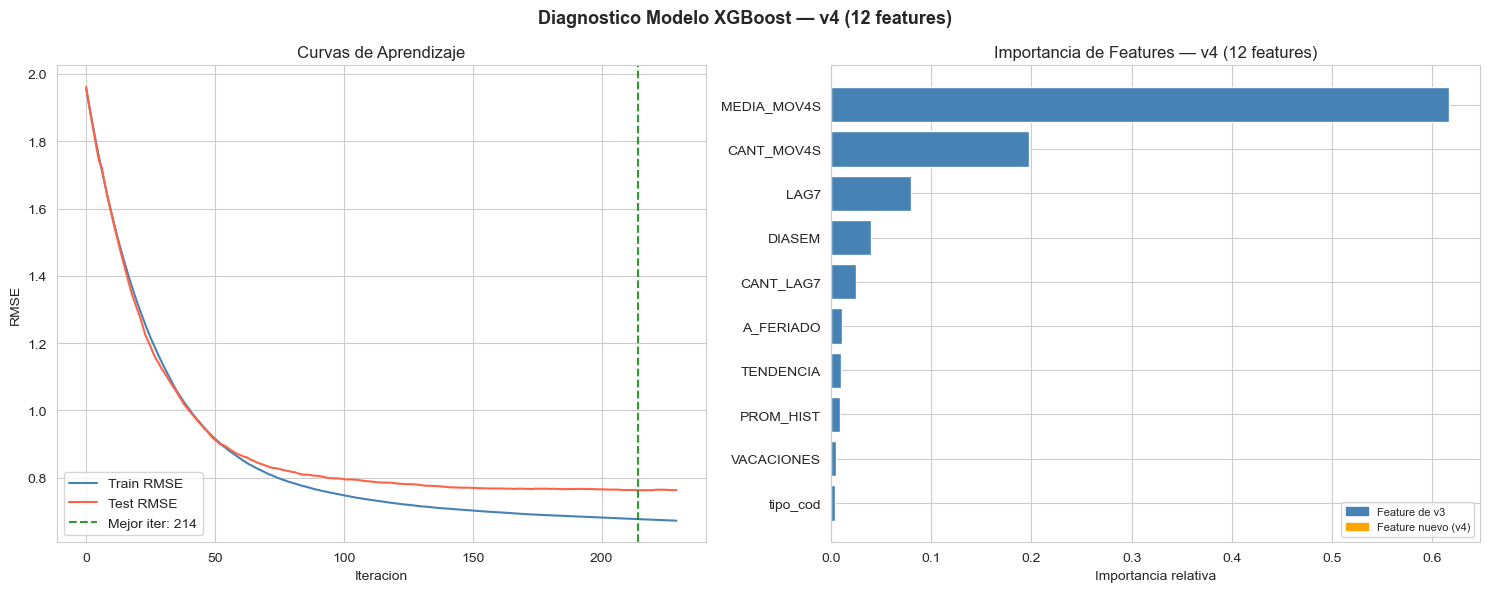

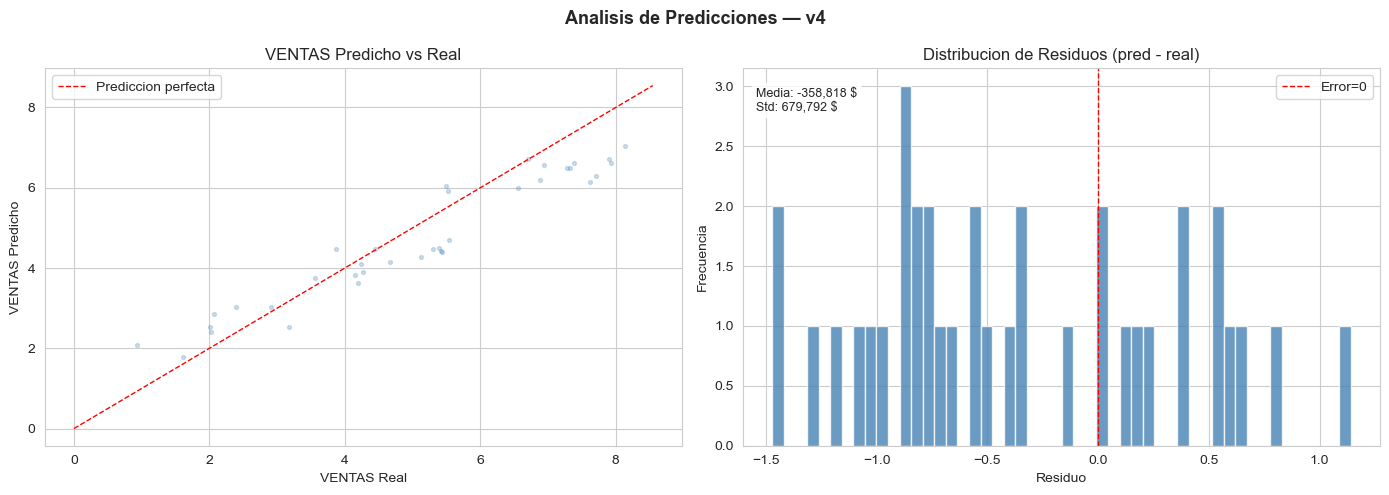

OK  Graficos guardados: grafico_aprendizaje_features_v4.png, grafico_predicho_residuos_v4.png


In [34]:
# ============================================================
# PASO 9: EVALUACION DEL MODELO v5 (10 features, autonomo)
# Test set: VALIDACION Mayo 2-15 (out-of-sample)
# Metricas: RMSE, MAE, R2, MAPE
# Graficos: curvas de aprendizaje, importancia (azul=v3, naranja=nuevo v4),
#           predicho vs real, distribucion de residuos.
# ============================================================

# ── Predecir sobre el conjunto de prueba ─────────────────
y_pred = model.predict(X_test)

# ── Calcular metricas de regresion ────────────────────────
# y_pred y y_test estan en MM$ (modelo escalado)
# RMSE y MAE se convierten a pesos (* ESCALA_MM) para interpretacion
rmse_val = np.sqrt(mean_squared_error(y_test, y_pred)) * ESCALA_MM
mae_val  = mean_absolute_error(y_test, y_pred) * ESCALA_MM
r2_val   = r2_score(y_test, y_pred)

# MAPE: ratio puro → no se ve afectado por la escala
mask_mape = y_test > 0
mape_val  = np.mean(np.abs((y_test[mask_mape] - y_pred[mask_mape]) / y_test[mask_mape])) * 100

# Sesgo medio en pesos
sesgo_medio = (y_pred - y_test.values).mean() * ESCALA_MM

# ── Interpretar R2 ────────────────────────────────────────
if r2_val >= 0.90:
    interp_r2 = "Excelente (>90% variabilidad explicada)"
elif r2_val >= 0.80:
    interp_r2 = "Muy bueno (80-90%)"
elif r2_val >= 0.70:
    interp_r2 = "Bueno (70-80%)"
elif r2_val >= 0.50:
    interp_r2 = "Moderado (50-70%) — hay margen de mejora"
else:
    interp_r2 = "Bajo (<50%) — revisar features y parametros"

print("=" * 70)
print("  METRICAS DE EVALUACION — MODELO v5 (10 features) [en pesos $] — VALIDACION Mayo 2-15")
print("=" * 70)
print(f"  RMSE      : $ {rmse_val:>14,.0f}   (error cuadratico en $)")
print(f"  MAE       : $ {mae_val:>14,.0f}   (error absoluto promedio en $)")
print(f"  R2        : {r2_val:>14.4f}   {interp_r2}")
print(f"  MAPE      : {mape_val:>13.2f}%   (error porcentual, excluye VENTAS=0)")
print(f"  Sesgo med : $ {sesgo_medio:>14,.0f}   (+ sobreestima / - subestima)")
print(f"\n  Media VENTAS real test ($)  : $ {y_test.mean() * ESCALA_MM:,.0f}")
print(f"  Mejor iteracion del modelo  : {n_opt}  (fase 1 early stopping)")

# ── Importancia de features con FEATURES_V4 ───────────────
# azul = features heredados de v3, naranja = features nuevos en v4
features_nuevos_v4 = {"CANT_VENTAS", "MEDIA_MOV4S_CANT"}

importancias = pd.Series(
    model.feature_importances_,
    index=FEATURES_V4
).sort_values()

# ── Grafico 1 y 2: curvas de aprendizaje + importancia ───
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Diagnostico Modelo XGBoost — v4 (12 features)", fontsize=13, fontweight="bold")

resultados = model_es.evals_result()  # fase 1: tiene eval_set con holdout
iters = range(len(resultados["validation_0"]["rmse"]))
axes[0].plot(iters, resultados["validation_0"]["rmse"], label="Train RMSE", color="steelblue", lw=1.5)
axes[0].plot(iters, resultados["validation_1"]["rmse"], label="Test RMSE",  color="tomato",    lw=1.5)
axes[0].axvline(x=n_opt, color="green", linestyle="--", alpha=0.8,
                label=f"Mejor iter: {n_opt}")
axes[0].set_title("Curvas de Aprendizaje")
axes[0].set_xlabel("Iteracion")
axes[0].set_ylabel("RMSE")
axes[0].legend()

colores = ["orange" if f in features_nuevos_v4 else "steelblue" for f in importancias.index]
axes[1].barh(range(len(importancias)), importancias.values, color=colores, edgecolor="white")
axes[1].set_yticks(range(len(importancias)))
axes[1].set_yticklabels(importancias.index)
axes[1].set_title("Importancia de Features — v4 (12 features)")
axes[1].set_xlabel("Importancia relativa")
axes[1].legend(
    handles=[
        plt.Rectangle((0,0),1,1, color="steelblue", label="Feature de v3"),
        plt.Rectangle((0,0),1,1, color="orange",    label="Feature nuevo (v4)"),
    ],
    loc="lower right", fontsize=8
)

plt.tight_layout()
plt.savefig("grafico_aprendizaje_features_v4.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Grafico 3 y 4: predicho vs real + residuos ───────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Analisis de Predicciones — v4", fontsize=13, fontweight="bold")

axes2[0].scatter(y_test, y_pred, alpha=0.25, s=8, color="steelblue")
lim_max = float(max(y_test.max(), y_pred.max())) * 1.05
axes2[0].plot([0, lim_max], [0, lim_max], "r--", linewidth=1, label="Prediccion perfecta")
axes2[0].set_title("VENTAS Predicho vs Real")
axes2[0].set_xlabel("VENTAS Real")
axes2[0].set_ylabel("VENTAS Predicho")
axes2[0].legend()

residuos = y_pred - y_test.values
axes2[1].hist(residuos, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes2[1].axvline(x=0, color="red", linestyle="--", linewidth=1, label="Error=0")
axes2[1].set_title("Distribucion de Residuos (pred - real)")
axes2[1].set_xlabel("Residuo")
axes2[1].set_ylabel("Frecuencia")
axes2[1].legend()
axes2[1].text(0.02, 0.95, f"Media: {residuos.mean()*ESCALA_MM:,.0f} $\nStd: {residuos.std()*ESCALA_MM:,.0f} $",
              transform=axes2[1].transAxes, va="top", fontsize=9,
              bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("grafico_predicho_residuos_v4.png", dpi=150, bbox_inches="tight")
plt.show()

print("OK  Graficos guardados: grafico_aprendizaje_features_v4.png, grafico_predicho_residuos_v4.png")


## Paso 10 — Recomendaciones de ajuste
El modelo genera automáticamente sugerencias de ajuste de parámetros basadas en los resultados,
identifica los features más y menos importantes, y propone nuevas variables a explorar.

In [35]:
# ============================================================
# PASO 10: RECOMENDACIONES DE AJUSTE — MODELO v4 (12 features)
# Diagnostica resultados y sugiere ajustes de parametros.
# ============================================================

rmse_train_fin = resultados["validation_0"]["rmse"][n_opt]
rmse_test_fin  = resultados["validation_1"]["rmse"][n_opt]
ratio_ov       = rmse_test_fin / rmse_train_fin if rmse_train_fin > 0 else float('inf')

print("=" * 70)
print("  DIAGNOSTICO Y RECOMENDACIONES — MODELO v4")
print("=" * 70)
print(f"  RMSE Train (mejor iter) : {rmse_train_fin:,.2f}")
print(f"  RMSE Test  (mejor iter) : {rmse_test_fin:,.2f}")
print(f"  Ratio Test/Train        : {ratio_ov:.2f}x  (>1.5 sugiere overfitting)")

print("\n-- AJUSTE DE PARAMETROS --")
if r2_val < 0.70:
    print("  R2 bajo (<0.70) — underfitting:")
    print("    -> Aumentar n_estimators a 2000, bajar learning_rate a 0.01")
    print("    -> Probar max_depth=4 o max_depth=6")
elif r2_val < 0.85:
    print("  R2 moderado (0.70-0.85) — mejora posible:")
    print("    -> Probar n_estimators=2000 con learning_rate=0.01")
    print("    -> Ajustar max_depth: probar 4 y 5")
    print("    -> Evaluar features de baja importancia (ver abajo)")
else:
    print("  R2 bueno (>0.85) — modelo v4 funciona bien.")
    print("    -> Tuning fino con Optuna si se busca mejora marginal")

if ratio_ov > 1.5:
    print("\n  OVERFITTING detectado (test >> train):")
    print("    -> Reducir max_depth a 3")
    print("    -> Bajar subsample y colsample_bytree a 0.7")
    print("    -> Aumentar min_child_weight a 5")
else:
    print("\n  Sin overfitting significativo")

# ── Importancia con FEATURES_V4 (12 features) ─────────────
features_nuevos_v4 = {"CANT_VENTAS", "MEDIA_MOV4S_CANT"}
importancias_ord = pd.Series(
    model.feature_importances_,
    index=FEATURES_V4
).sort_values(ascending=False)

print("\n-- TOP 6 FEATURES MAS IMPORTANTES (v4) --")
for i, (feat, imp) in enumerate(importancias_ord.head(6).items(), 1):
    tag = "(nuevo v4)" if feat in features_nuevos_v4 else "          "
    barra = chr(9608) * int(imp * 60)
    print(f"  {i}. {feat:<22} {tag}: {imp:.4f}  {barra}")

print("\n-- BOTTOM 3 FEATURES DE MENOR IMPORTANCIA EN v4 --")
for feat, imp in importancias_ord.tail(3).items():
    tag = "(nuevo v4)" if feat in features_nuevos_v4 else "          "
    print(f"  {feat:<22} {tag}: {imp:.4f}  -> evaluar si aporta valor")

print("\n-- EVALUACION FEATURES NUEVOS v4 --")
for feat in sorted(features_nuevos_v4):
    if feat in importancias_ord.index:
        imp  = importancias_ord[feat]
        rank = list(importancias_ord.index).index(feat) + 1
        nivel = "ALTO" if imp > 0.10 else ("MEDIO" if imp > 0.05 else "BAJO")
        print(f"  {feat:<22}: imp={imp:.4f}  rank={rank}/{len(FEATURES_V4)}  nivel={nivel}")

print("\n-- PROXIMOS PASOS (si R2 < 0.90) --")
print("  1. RATIO_MOV4S = MEDIA_MOV4S / PROM_HIST (ratio vs historico)")
print("  2. Vacaciones_invierno: calendario MINEDUC de inicio/fin de clases")
print("  3. Lag por dia de semana: ventas del lunes anterior, martes anterior, etc.")
print("  4. EMA7: media exponencial ponderada (mas peso a dias recientes que MEDIA_MOV4S)")


  DIAGNOSTICO Y RECOMENDACIONES — MODELO v4
  RMSE Train (mejor iter) : 0.68
  RMSE Test  (mejor iter) : 0.76
  Ratio Test/Train        : 1.13x  (>1.5 sugiere overfitting)

-- AJUSTE DE PARAMETROS --
  R2 bueno (>0.85) — modelo v4 funciona bien.
    -> Tuning fino con Optuna si se busca mejora marginal

  Sin overfitting significativo

-- TOP 6 FEATURES MAS IMPORTANTES (v4) --
  1. MEDIA_MOV4S                      : 0.6166  ████████████████████████████████████
  2. CANT_MOV4S                       : 0.1975  ███████████
  3. LAG7                             : 0.0803  ████
  4. DIASEM                           : 0.0398  ██
  5. CANT_LAG7                        : 0.0252  █
  6. A_FERIADO                        : 0.0111  

-- BOTTOM 3 FEATURES DE MENOR IMPORTANCIA EN v4 --
  PROM_HIST                        : 0.0093  -> evaluar si aporta valor
  VACACIONES                       : 0.0054  -> evaluar si aporta valor
  tipo_cod                         : 0.0043  -> evaluar si aporta valor

-- 

## Paso 11 — Guardar el modelo
Guarda el modelo en 2 formatos para distintos usos:
- `.json`: portable entre versiones de XGBoost
- `.pkl`: carga rápida en Python

In [36]:
# ============================================================
# PASO 11: GUARDAR EL MODELO v4 Y VARIABLES AUXILIARES
#   xgb_ventas_clinica_v4.json -> modelo nativo XGBoost
#   xgb_ventas_clinica_v4.pkl  -> modelo pickle
#   label_encoder.pkl          -> encoder Tipo Consulta
#   features_v4.pkl            -> lista FEATURES_V4 (12 features)
#   prom_hist_dict.pkl         -> promedios historicos VENTAS
#   prom_cant_dict.pkl         -> promedios historicos CANT_VENTAS
#   fecha_inicio.pkl           -> fecha base TENDENCIA
#   feriados_set.pkl           -> set de feriados
# ============================================================

import pickle, os

model.save_model('xgb_ventas_clinica_v5.json')
pickle.dump(model,          open('xgb_ventas_clinica_v5.pkl', 'wb'))
pickle.dump(FEATURES_V5,    open('features_v5.pkl',           'wb'))
pickle.dump(PROM_HIST_DICT, open('prom_hist_dict.pkl',        'wb'))
pickle.dump(PROM_CANT_DICT, open('prom_cant_dict.pkl',        'wb'))
pickle.dump(le,             open('label_encoder.pkl',         'wb'))
pickle.dump(FECHA_INICIO,   open('fecha_inicio.pkl',          'wb'))
_feriados_set = LISTA_FERIADOS
pickle.dump(_feriados_set,  open('feriados_set.pkl',          'wb'))

archivos = {
    'xgb_ventas_clinica_v5.json': 'modelo XGBoost v5 (nativo)',
    'xgb_ventas_clinica_v5.pkl' : 'modelo XGBoost v5 (pickle)',
    'label_encoder.pkl'          : 'encoder Tipo Consulta',
    'features_v5.pkl'            : 'lista FEATURES_V5 (10 features, autonomo)',
    'prom_hist_dict.pkl'         : f'promedios VENTAS hasta {FECHA_INICIO.date()} + Abr2026',
    'prom_cant_dict.pkl'         : 'promedios CANT hasta Abr2026',
    'fecha_inicio.pkl'           : f'fecha base TENDENCIA ({FECHA_INICIO.date()})',
    'feriados_set.pkl'           : f'set de feriados ({len(_feriados_set)} fechas)',
}

print('=' * 65)
print('  ARCHIVOS GUARDADOS — MODELO v5 (autonomo, train hasta Abr2026)')
print('=' * 65)
for archivo, desc in archivos.items():
    if os.path.exists(archivo):
        kb = os.path.getsize(archivo) / 1024
        print(f'  OK  {archivo:<38} ({kb:6.1f} KB)  {desc}')
    else:
        print(f'  X   {archivo:<38}  NO SE GUARDO')

print(f'\n  Directorio: {os.getcwd()}')
print('\nOK  Modelo v5 guardado correctamente.')


  ARCHIVOS GUARDADOS — MODELO v5 (autonomo, train hasta Abr2026)
  OK  xgb_ventas_clinica_v5.json             ( 422.3 KB)  modelo XGBoost v5 (nativo)
  OK  xgb_ventas_clinica_v5.pkl              ( 394.0 KB)  modelo XGBoost v5 (pickle)
  OK  label_encoder.pkl                      (   0.4 KB)  encoder Tipo Consulta
  OK  features_v5.pkl                        (   0.1 KB)  lista FEATURES_V5 (10 features, autonomo)
  OK  prom_hist_dict.pkl                     (   1.0 KB)  promedios VENTAS hasta 2023-04-01 + Abr2026
  OK  prom_cant_dict.pkl                     (   1.0 KB)  promedios CANT hasta Abr2026
  OK  fecha_inicio.pkl                       (   0.1 KB)  fecha base TENDENCIA (2023-04-01)
  OK  feriados_set.pkl                       (   1.2 KB)  set de feriados (88 fechas)

  Directorio: C:\Users\ferre\Documents\MODELOS_PREDICCION\CEAPSI

OK  Modelo v5 guardado correctamente.


## Paso 12 — Verificación: A_FERIADO
Muestra ejemplos del flag `A_FERIADO` que usa `PrediVtasMes` para predecir:

- `A_FERIADO = 1` si el día siguiente es feriado (reduce afluencia el día previo)

Fuente: `LISTA_FERIADOS` cargada de `mantencion.xlsx` en Paso 2b.

In [37]:
# ============================================================
# PASO 12: VERIFICACION — A_FERIADO ("manana es feriado")
# Unico flag de feriado binario en FEATURES_V4.
# A_FERIADO = 1 si Fecha+1 dia es feriado.
#   Efecto: la vispera de un feriado tiene menor afluencia.
# Fuente: LISTA_FERIADOS (mantencion.xlsx, Paso 2b).
# En entrenamiento: calculado vectorizado en Paso 5.
# En prediccion:    calculado dia a dia en Paso 13.
# ============================================================

# ── Tabla de verificacion: 5 fechas de ejemplo ───────────
print('=' * 65)
print('  VERIFICACION A_FERIADO — "manana es feriado?"')
print('=' * 65)

feriados_list = sorted(LISTA_FERIADOS)
fechas_ejemplo = []
if feriados_list:
    f0 = feriados_list[0]
    fechas_ejemplo += [f0 - timedelta(days=1), f0, f0 + timedelta(days=1)]
    if len(feriados_list) > 1:
        f1 = feriados_list[1]
        fechas_ejemplo.append(f1 - timedelta(days=1))
# Dia normal de mitad de anio
fechas_ejemplo.append(date_type(feriados_list[0].year, 6, 15))

rows_ej = []
for f in fechas_ejemplo[:5]:
    sig = f + timedelta(days=1)
    a_feriado = 1 if sig in LISTA_FERIADOS else 0
    rows_ej.append({
        'Fecha':       f,
        'DiaSem':      f.isoweekday(),
        'Es feriado?': 'SI' if f in LISTA_FERIADOS else 'no',
        'A_FERIADO':   a_feriado,
        'Motivo':      'manana feriado' if a_feriado else '-',
    })
display(pd.DataFrame(rows_ej))

print(f'\n  Total feriados en LISTA_FERIADOS: {len(LISTA_FERIADOS)}')
print('OK  A_FERIADO verificado.')
print('    En Paso 5: calculado vectorizado para df_train_full y df_test_full.')
print('    En Paso 13: calculado por dia en PrediVtasMes._feriado_flags.')


  VERIFICACION A_FERIADO — "manana es feriado?"


,Fecha,DiaSem,Es feriado?,A_FERIADO,Motivo
0,2021-12-31,5,no,1,manana feriado
1,2022-01-01,6,SI,0,-
2,2022-01-02,7,no,0,-
3,2022-04-14,4,no,1,manana feriado
4,2022-06-15,3,no,0,-



  Total feriados en LISTA_FERIADOS: 88
OK  A_FERIADO verificado.
    En Paso 5: calculado vectorizado para df_train_full y df_test_full.
    En Paso 13: calculado por dia en PrediVtasMes._feriado_flags.


## Paso 13 — `PrediVtasMes(mes, año)`: predicción mensual
Predice las ventas diarias para cada tipo de consulta durante todo un mes.
Retorna una tabla diaria pivoteada y un resumen acumulado por tipo + total del mes.

> Modificar `MES_PRED` y `ANO_PRED` al final de la celda para predecir cualquier mes.

In [38]:
# ============================================================
# PASO 13: PrediVtasMes + estimar_factor_cobertura — VERSION 4
#
# FLUJO DE USO:
#   1. Cargar reservas confirmadas a la fecha en cant_dia
#   2. Llamar estimar_factor_cobertura() para obtener el factor
#      que proyecta las reservas actuales al total esperado del mes
#   3. Llamar PrediVtasMes() con cant_dia + factor_proyeccion
#
# CANT_VENTAS en el modelo:
#   - dias con reservas conocidas: cant_dia × factor_proyeccion
#   - dias sin reservas conocidas: CANT_MOV4S (media 4 sem. mismo dia de semana)
# ============================================================

import pickle, calendar as _cal
from datetime import date as _date, timedelta as _td

_ESCALA_MM = 1_000_000
_TIPO_MAP  = {'Adultos': 0, 'Infantil': 1, 'Teleconsulta': 2}
_TIPOS     = ['Adultos', 'Infantil', 'Teleconsulta']


def estimar_factor_cobertura(cant_dia_actual, mes, prom_cant_dict, verbose=True):
    """
    Estima el factor de proyeccion por tipo comparando las reservas
    actuales con el promedio historico para esos mismos dias.

    Logica:
      Para cada tipo, suma las reservas confirmadas en cant_dia_actual
      y las compara con lo que historicamente deberia haber en esos
      mismos dias: prom_hist_diario × cantidad_de_dias_con_datos.
      factor_tipo = esperado_hist / reservado_actual

    Parametros
    ----------
    cant_dia_actual : dict {(date, tipo_str): cantidad}
                      reservas confirmadas hasta hoy
    mes             : mes que se quiere predecir
    prom_cant_dict  : dict {(mes, tipo_cod): prom_diario_hist}
    verbose         : imprimir tabla de factores

    Retorna
    -------
    dict {'Adultos': f_a, 'Infantil': f_i, 'Teleconsulta': f_t, 'TOTAL': f_global}
    """
    suma_actual   = {t: 0.0 for t in _TIPOS}
    dias_por_tipo = {t: 0   for t in _TIPOS}

    for (fecha, tipo), cant in cant_dia_actual.items():
        if tipo in suma_actual:
            suma_actual[tipo]   += float(cant)
            dias_por_tipo[tipo] += 1

    factores = {}
    for tipo in _TIPOS:
        tc     = _TIPO_MAP[tipo]
        n_dias = dias_por_tipo[tipo]
        actual = suma_actual[tipo]
        if n_dias == 0 or actual == 0:
            factores[tipo] = 1.0   # sin datos: no ajustar
            continue
        prom_hist          = prom_cant_dict.get((mes, tc), 0.0)
        esperado_hist      = prom_hist * n_dias
        factores[tipo]     = esperado_hist / actual if actual > 0 else 1.0

    total_actual   = sum(suma_actual.values())
    total_esperado = sum(
        prom_cant_dict.get((mes, _TIPO_MAP[t]), 0.0) * dias_por_tipo[t]
        for t in _TIPOS
    )
    factores['TOTAL'] = total_esperado / total_actual if total_actual > 0 else 1.0

    if verbose:
        print('=' * 65)
        print(f'  FACTOR DE PROYECCION — cobertura actual vs historico (mes {mes})')
        print('=' * 65)
        print(f'  {"Tipo":<15} {"Dias c/datos":>12} {"Reservado":>12} {"Esperado hist":>14} {"Factor":>8}')
        print('-' * 65)
        for tipo in _TIPOS:
            tc        = _TIPO_MAP[tipo]
            n         = dias_por_tipo[tipo]
            actual    = suma_actual[tipo]
            esp       = prom_cant_dict.get((mes, tc), 0.0) * n
            f         = factores[tipo]
            print(f'  {tipo:<15} {n:>12} {actual:>12.0f} {esp:>14.0f} {f:>7.2f}x')
        print('-' * 65)
        print(f'  {"TOTAL":<15} {"":>12} {total_actual:>12.0f} {total_esperado:>14.0f} {factores["TOTAL"]:>7.2f}x')
        print()
        print('  Interpretacion:')
        print(f'    Factor > 1 → reservas actuales estan por debajo del historico (normal al inicio del mes)')
        print(f'    Factor ~ 1 → cobertura completa, reservas ya representan el mes')

    return factores


def PrediVtasMes(mes, año,
                 model_obj=None, le_obj=None, feriados_set=None,
                 prom_hist_dict=None, prom_cant_dict=None,
                 fecha_inicio_train=None, df_historico_lag=None,
                 cant_dia=None, factor_proyeccion=None):
    """
    Predice ventas diarias para el mes/año indicado.

    Parametros clave
    ----------------
    cant_dia          : dict {(date, tipo_str): cant_reservada}
                        Reservas confirmadas a la fecha.
                        Si None → usa PROM_CANT_DICT para todos los dias.
    factor_proyeccion : float o dict {tipo: factor} o 'auto'
                        Escala cant_dia al total esperado del mes.
                        - float : mismo factor para todos los tipos
                        - dict  : factor por tipo (resultado de estimar_factor_cobertura)
                        - 'auto': calcula el factor automaticamente con estimar_factor_cobertura
                        - None  : usa cant_dia sin escalar (cobertura 100%)

    Variables monetarias en MM$ (÷ 1,000,000); resultado en pesos ($).
    """
    _model  = model_obj          or pickle.load(open('xgb_ventas_clinica_v5.pkl', 'rb'))
    _le     = le_obj             or pickle.load(open('label_encoder.pkl',          'rb'))
    _feries = feriados_set       or pickle.load(open('feriados_set.pkl',           'rb'))
    _prom   = prom_hist_dict     or pickle.load(open('prom_hist_dict.pkl',         'rb'))
    _prom_c = prom_cant_dict     or pickle.load(open('prom_cant_dict.pkl',         'rb'))
    _t0     = fecha_inicio_train or pickle.load(open('fecha_inicio.pkl',           'rb'))

    def _to_date(v):
        return v if isinstance(v, _date) else pd.Timestamp(v).date()
    _feries = {_to_date(f) for f in _feries}

    # ── Resolver factor_proyeccion ──────────────────────────
    if factor_proyeccion == 'auto' and cant_dia:
        _factores = estimar_factor_cobertura(cant_dia, mes, _prom_c, verbose=True)
    elif isinstance(factor_proyeccion, dict):
        _factores = factor_proyeccion
    elif isinstance(factor_proyeccion, (int, float)):
        _factores = {t: float(factor_proyeccion) for t in _TIPOS}
        _factores['TOTAL'] = float(factor_proyeccion)
    else:
        _factores = {t: 1.0 for t in _TIPOS + ['TOTAL']}

    def _get_factor(tipo):
        return _factores.get(tipo, 1.0)

    total_dias = _cal.monthrange(año, mes)[1]

    # Cache de lags en MM$ (VENTAS) y conteos (CANT)
    cache_v = {}
    cache_c = {}
    if df_historico_lag is not None:
        for _, row in df_historico_lag.iterrows():
            f  = _to_date(row['Fecha'])
            tc = int(row['tipo_cod'])
            cache_v[(f, tc)] = float(row['VENTAS']) / _ESCALA_MM
            cache_c[(f, tc)] = float(row.get('CANT_VENTAS', 0))

    def _get_lag_v(fd, tc, dias):
        k = (fd - _td(days=dias), tc)
        return cache_v.get(k, _prom.get((mes, tc), 0.0) / _ESCALA_MM)

    def _get_lag_c(fd, tc, dias):
        k = (fd - _td(days=dias), tc)
        return cache_c.get(k, _prom_c.get((mes, tc), 0.0))

    def _a_feriado(fd):
        return 1 if (fd + _td(days=1)) in _feries else 0

    def _vac(m, d):
        if m == 12 and d >= 26: return 1
        if m in (1, 2):          return 1
        if m == 3 and d == 1:   return 1
        return 0

    def _cant_mov4s(fd, tc):
        """Media 4 semanas de CANT_VENTAS para el mismo dia de semana.
        Lags -7/-14/-21/-28 dias garantizan mismo weekday en cada punto."""
        vals = [cache_c.get((fd - _td(days=d * 7), tc), 0.0) for d in range(1, 5)]
        vals = [v for v in vals if v > 0]
        return sum(vals) / len(vals) if vals else _prom_c.get((fd.month, tc), 0.0)

    # Factor de correccion multiplicativo global (+6.3% sesgo sistematico del modelo)
    # Calibrado sobre test Feb-Abr 2026: suma pred / suma real = 1/1.063
    FACTOR_CORRECCION = 1.063

    def _cant_lag7(fd, tc):
        """CANT_VENTAS de la semana anterior (mismo dia de semana)."""
        return cache_c.get((fd - _td(days=7), tc), _prom_c.get((fd.month, tc), 0.0))

    filas = []
    for dia in range(1, total_dias + 1):
        fecha  = _date(año, mes, dia)
        diasem = fecha.isoweekday()

        for tipo in _TIPOS:
            tc = int(_le.transform([tipo])[0])

            lag7  = _get_lag_v(fecha, tc,  7)
            lag14 = _get_lag_v(fecha, tc, 14)
            lag21 = _get_lag_v(fecha, tc, 21)
            lag28 = _get_lag_v(fecha, tc, 28)
            mmov  = (lag7 + lag14 + lag21 + lag28) / 4.0

            # CANT_VENTAS: reserva conocida × factor; resto: mov4s mismo dia semana
            if cant_dia and (fecha, tipo) in cant_dia:
                cant = float(cant_dia[(fecha, tipo)]) * _get_factor(tipo)
            else:
                cant = _cant_mov4s(fecha, tc)

            if diasem == 7 or fecha in _feries:
                ventas_pred_mm = 0.0
                cant = 0.0
            else:
                X_pred = pd.DataFrame([{
                    'DIASEM'    : diasem,
                    'tipo_cod'  : tc,
                    'A_FERIADO' : _a_feriado(fecha),
                    'TENDENCIA' : (pd.Timestamp(fecha) - pd.Timestamp(_t0)).days,
                    'PROM_HIST' : _prom.get((mes, tc), 0.0) / _ESCALA_MM,
                    'LAG7'      : lag7,
                    'MEDIA_MOV4S': mmov,
                    'VACACIONES' : _vac(mes, dia),
                    'CANT_LAG7'  : _cant_lag7(fecha, tc),
                    'CANT_MOV4S' : cant,
                }])
                ventas_pred_mm = max(float(_model.predict(X_pred)[0]), 0.0)

            cache_v[(fecha, tc)] = ventas_pred_mm
            cache_c[(fecha, tc)] = cant

            filas.append({
                'Fecha'        : fecha,
                'Dia'          : dia,
                'DiaSem'       : diasem,
                'Tipo Consulta': tipo,
                'CANT_VENTAS'  : round(cant, 1),
                'VENTAS_PRED'  : round(ventas_pred_mm * _ESCALA_MM, 0),
            })

    df_diario = pd.DataFrame(filas)
    df_pivot  = df_diario.pivot_table(
        index=['Fecha', 'Dia', 'DiaSem'],
        columns='Tipo Consulta', values='VENTAS_PRED', aggfunc='sum'
    ).reset_index()
    df_pivot['TOTAL_DIA'] = df_pivot[[t for t in _TIPOS if t in df_pivot.columns]].sum(axis=1)

    df_res = df_diario.groupby('Tipo Consulta')['VENTAS_PRED'].sum().reset_index()
    df_res.columns = ['Tipo Consulta', 'VENTAS_MES']
    # Aplicar factor de correccion multiplicativo (+6.3%) al total
    total_sin_factor = df_res['VENTAS_MES'].sum()
    total_con_factor = total_sin_factor * FACTOR_CORRECCION
    df_res = pd.concat([
        df_res,
        pd.DataFrame([{'Tipo Consulta': 'TOTAL (sin factor)', 'VENTAS_MES': total_sin_factor}]),
        pd.DataFrame([{'Tipo Consulta': f'TOTAL x{FACTOR_CORRECCION}', 'VENTAS_MES': total_con_factor}]),
    ], ignore_index=True)

    # Imprimir tabla
    ds = {1:'Lun',2:'Mar',3:'Mie',4:'Jue',5:'Vie',6:'Sab',7:'Dom'}
    ndm = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
           7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
    ct = [t for t in _TIPOS if t in df_pivot.columns]
    print('=' * 82)
    print(f'  PREDICCION {ndm.get(mes,mes)} {año}  |  modelo v5 / 10 features / autonomo / factor x{FACTOR_CORRECCION}')
    if factor_proyeccion is not None:
        print(f'  Factor cobertura aplicado: {_factores}')
    print('=' * 82)
    hdr = f"{'Fecha':<12} {'DS':<4}" + ''.join(f' {t[:10]:>15}' for t in ct) + f' {"TOTAL":>13}'
    print(hdr); print('-'*len(hdr))
    for _, row in df_pivot.iterrows():
        d  = ds.get(int(row['DiaSem']),'?')
        ln = f'{str(row["Fecha"]):<12} {d:<4}' + ''.join(f' {row.get(t,0):>15,.0f}' for t in ct)
        ln += f' {row["TOTAL_DIA"]:>13,.0f}'
        if int(row['DiaSem']) == 7: ln += '  [dom]'
        print(ln)
    print('-'*len(hdr))
    print('\n  RESUMEN MENSUAL:')
    for _, row in df_res.iterrows():
        print(f'    {row["Tipo Consulta"]:<20}: $ {row["VENTAS_MES"]:>14,.0f}')
    return df_pivot, df_res


# ── EJEMPLOS DE USO ─────────────────────────────────────────────────────────
print('MODO 1 — Solo mes/año (sin reservas, usa promedios historicos):')
print('  df_pivot, df_res = PrediVtasMes(mes=7, año=2026)')
print()
print('MODO 2 — Con reservas confirmadas + factor automatico:')
print('  # Ejemplo: reservas cargadas al dia 2 del mes anterior')
print('  cant_dia = {')
print('      (date(2026,7,1), "Adultos"): 12,')
print('      (date(2026,7,1), "Infantil"): 5,')
print('      (date(2026,7,2), "Adultos"): 18,')
print('      # ... resto de dias a medida que se confirman')
print('  }')
print('  factores = estimar_factor_cobertura(cant_dia, mes=7, prom_cant_dict=PROM_CANT_DICT)')
print('  df_pivot, df_res = PrediVtasMes(mes=7, año=2026,')
print('      cant_dia=cant_dia, factor_proyeccion=factores,')
print('      model_obj=model, le_obj=le, feriados_set=LISTA_FERIADOS,')
print('      prom_hist_dict=PROM_HIST_DICT, prom_cant_dict=PROM_CANT_DICT,')
print('      fecha_inicio_train=FECHA_INICIO, df_historico_lag=df_todo_lag)')
print()
print('MODO 3 — Con reservas + factor manual (ej: se que estoy al 30% de cobertura):')
print('  df_pivot, df_res = PrediVtasMes(mes=7, año=2026,')
print('      cant_dia=cant_dia, factor_proyeccion=1/0.30)')
print()

# Correr prediccion modo 1 como demo
mes_pred = 7; año_pred = 2026
print(f'--- Corriendo demo Modo 1: {mes_pred}/{año_pred} ---')
df_pivot_pred, df_res_pred = PrediVtasMes(
    mes=mes_pred, año=año_pred,
    model_obj=model, le_obj=le,
    feriados_set=LISTA_FERIADOS,
    prom_hist_dict=PROM_HIST_DICT,
    prom_cant_dict=PROM_CANT_DICT,
    fecha_inicio_train=FECHA_INICIO,
    df_historico_lag=df_todo_lag,
)


MODO 1 — Solo mes/año (sin reservas, usa promedios historicos):
  df_pivot, df_res = PrediVtasMes(mes=7, año=2026)

MODO 2 — Con reservas confirmadas + factor automatico:
  # Ejemplo: reservas cargadas al dia 2 del mes anterior
  cant_dia = {
      (date(2026,7,1), "Adultos"): 12,
      (date(2026,7,1), "Infantil"): 5,
      (date(2026,7,2), "Adultos"): 18,
      # ... resto de dias a medida que se confirman
  }
  factores = estimar_factor_cobertura(cant_dia, mes=7, prom_cant_dict=PROM_CANT_DICT)
  df_pivot, df_res = PrediVtasMes(mes=7, año=2026,
      cant_dia=cant_dia, factor_proyeccion=factores,
      model_obj=model, le_obj=le, feriados_set=LISTA_FERIADOS,
      prom_hist_dict=PROM_HIST_DICT, prom_cant_dict=PROM_CANT_DICT,
      fecha_inicio_train=FECHA_INICIO, df_historico_lag=df_todo_lag)

MODO 3 — Con reservas + factor manual (ej: se que estoy al 30% de cobertura):
  df_pivot, df_res = PrediVtasMes(mes=7, año=2026,
      cant_dia=cant_dia, factor_proyeccion=1/0.30)

--- Corriend

In [ ]:
# ============================================================
# PASO 15: CICLO DE MANTENCION MENSUAL
# ============================================================
# Cuándo ejecutar: al cierre de cada mes, con el mes completo en PRUEBA.
#
#   Fase Validación  : el notebook ya corrió (Pasos 1-14) con PRUEBA = mes
#                      evaluado. Aquí se decide si el modelo aprueba.
#
#   Fase Producción  : si aprueba, se reentrena con todo el histórico
#                      (ENTRENAMIENTO + PRUEBA juntos) y se sobrescriben
#                      los artefactos v5 listos para predecir el mes siguiente.
#
#   Si no aprueba    : el modelo anterior sigue activo y se registra
#                      la alerta en mantencion_log.txt para revisión manual.
# ============================================================
import datetime as _dt

# ── Umbrales de aprobación ───────────────────────────────────────────
UMBRAL_R2   = 0.75   # R² mínimo (75% variabilidad explicada)
UMBRAL_MAPE = 18.0   # MAPE máximo en % (error porcentual medio)
LOG_FILE    = 'mantencion_log.txt'

# ── Métricas del mes de prueba (ya calculadas en Paso 9) ─────────────
# r2_val   : R² sobre y_test (MM$, escala interna — dimensionless, ok)
# mape_val : MAPE en % sobre y_test > 0
_now_str  = _dt.datetime.now().strftime('%Y-%m-%d %H:%M')
_aprobado = (r2_val >= UMBRAL_R2) and (mape_val <= UMBRAL_MAPE)

print("=" * 66)
print("  CICLO DE MANTENCION — DECISION DE PASO A PRODUCCION")
print("=" * 66)
print(f"  Fecha evaluacion  : {_now_str}")
print(f"  R²   del mes      : {r2_val:.4f}   (umbral ≥ {UMBRAL_R2})")
print(f"  MAPE del mes      : {mape_val:.1f}%   (umbral ≤ {UMBRAL_MAPE}%)")
print()

if _aprobado:
    # ════════════════════════════════════════════════════════════════
    # FASE PRODUCCION: reentrenar con historico completo (train + prueba)
    # ════════════════════════════════════════════════════════════════
    print("  ESTADO : APROBADO ✓")
    print("  Accion : reentrenando con historico completo (train + prueba)...")
    print()

    # Combinar train y test ya escalados y con features calculadas
    df_full_prod = (pd.concat([df_train_v4, df_test_v4], ignore_index=True)
                      .sort_values('Fecha')
                      .reset_index(drop=True))

    X_prod = df_full_prod[FEATURES_V5]
    y_prod = df_full_prod[TARGET]

    # Holdout para early stopping: últimas 8 semanas del histórico completo
    _corte_ho = df_full_prod['Fecha'].max() - pd.Timedelta(weeks=8)
    _mask_ho  = df_full_prod['Fecha'] >= _corte_ho
    X_es_p = df_full_prod[~_mask_ho][FEATURES_V5]
    y_es_p = df_full_prod[~_mask_ho][TARGET]
    X_ho_p = df_full_prod[ _mask_ho][FEATURES_V5]
    y_ho_p = df_full_prod[ _mask_ho][TARGET]

    print(f"  Train produccion  : {(~_mask_ho).sum()} filas")
    print(f"  Holdout ES        : {_mask_ho.sum()} filas "
          f"({df_full_prod[_mask_ho]['Fecha'].min().date()} → "
          f"{df_full_prod[_mask_ho]['Fecha'].max().date()})")

    # Fase 1: encontrar n_opt con early stopping sobre el holdout
    _model_es_p = xgb.XGBRegressor(**PARAMS_BASE, n_estimators=2000, early_stopping_rounds=15)
    _model_es_p.fit(X_es_p, y_es_p,
                    eval_set=[(X_es_p, y_es_p), (X_ho_p, y_ho_p)],
                    verbose=False)
    n_opt_prod = _model_es_p.best_iteration
    print(f"  n_opt produccion  : {n_opt_prod} arboles")

    # Fase 2: entrenar sobre TODO el historico con n_opt fijo
    model_prod = xgb.XGBRegressor(**PARAMS_BASE, n_estimators=n_opt_prod)
    model_prod.fit(X_prod, y_prod, verbose=False)

    # Guardar artefactos (sobreescribe v5 — listo para PrediVtasMes del mes siguiente)
    model_prod.save_model('xgb_ventas_clinica_v5.json')
    pickle.dump(model_prod, open('xgb_ventas_clinica_v5.pkl', 'wb'))
    print()
    print("  Artefactos guardados:")
    print("    xgb_ventas_clinica_v5.pkl  (pickle)")
    print("    xgb_ventas_clinica_v5.json (nativo XGBoost)")
    print()
    print("  SIGUIENTE PASO: mover PRUEBA → ENTRENAMIENTO en basefin1.xlsx")
    print("  y cargar el mes siguiente en PRUEBA antes del proximo ciclo.")

    # Registrar aprobación en log
    with open(LOG_FILE, 'a', encoding='utf-8') as _f:
        _f.write(
            f"[{_now_str}] APROBADO  "
            f"R2={r2_val:.4f}  MAPE={mape_val:.1f}%  "
            f"n_opt={n_opt_prod}  — artefactos actualizados\n"
        )

else:
    # ════════════════════════════════════════════════════════════════
    # FASE RECHAZO: conservar modelo anterior, emitir alerta
    # ════════════════════════════════════════════════════════════════
    print("  ESTADO : RECHAZADO ✗ — el modelo del mes anterior sigue en produccion")
    _motivos = []
    if r2_val   < UMBRAL_R2:
        _motivos.append(f"R²={r2_val:.4f} < umbral {UMBRAL_R2}")
    if mape_val > UMBRAL_MAPE:
        _motivos.append(f"MAPE={mape_val:.1f}% > umbral {UMBRAL_MAPE}%")
    print(f"  Motivo  : {' | '.join(_motivos)}")
    print()
    print("  *** NOTIFICACION ***")
    print("  El modelo NO fue actualizado. Acciones recomendadas:")
    print("   1. Revisar si los datos de PRUEBA tienen registros completos.")
    print("   2. Comparar distribucion de VENTAS con meses anteriores (outliers).")
    print("   3. Evaluar si hubo cambio estructural en la demanda.")
    print("   4. Ajustar hiperparametros o agregar nuevas features si es necesario.")
    print(f"  Detalle guardado en: {LOG_FILE}")

    # Registrar rechazo en log
    with open(LOG_FILE, 'a', encoding='utf-8') as _f:
        _f.write(
            f"[{_now_str}] RECHAZADO  "
            f"{' | '.join(_motivos)}  "
            f"— modelo NO actualizado. Revisar manualmente.\n"
        )

print()
print("=" * 66)
